# Proyecto 2º Corte: YOLO para detección de formas geométricas
**Electiva IV – Deep Computer Vision · USTA Bucaramanga**

Este notebook arma el proyecto **desde cero**: genera el dataset propio, entrena YOLO (≥ v8), calcula las métricas y deja lista la demo en tiempo real.

### Cómo usarlo
a **webcam** solo funciona en un computador local; en Colab la demo se prueba con un video (Parte 6).

### Mapa de partes
| Parte | Qué hace | Archivos que crea |
|---|---|---|
| 0 | Configura parámetros e instala librerías | – |
| 1 | Funciones compartidas (colores, IoU, dibujo) | `shapes_utils.py` |
| 2 | Genera y revisa el dataset sintético | `data/generate_dataset.py`, `data/shapes_yolo/` |
| 3 | Mezcla fotos reales de la webcam | `capture_frames.py`, `data/add_real_data.py` |
| 4 | Entrena YOLO y revisa si se saturó | `train.py`, `models/best.pt` |
| 5 | Métricas, matriz de confusión y Acc_val | `evaluate.py`, `models/metrics.json` |
| 6 | Demo en tiempo real | `demo_webcam.py` |
| 7 | Entregables (requirements y README) | `requirements.txt`, `README.md` |
| 8 | Descarga del modelo para probarlo en su PC | `modelo_yolo.zip` |
| 9 | Conclusiones (las escriben ustedes) | – |

---
# PARTE 0 · Configuración
> **¿Qué hace esta parte?** Define los parámetros del proyecto en un solo lugar (cantidad de imágenes, épocas, tamaño de lote y modelo base), instala las librerías que faltan y crea las carpetas de trabajo.
> **Qué cambiar:** solo los cuatro valores de arriba de la celda. `BATCH` se baja a 8 si la GPU se queda sin memoria.

In [1]:
# ---- Configuración (cambien aquí los parámetros) ----
N_IMGS = 1800                # imágenes sintéticas totales (mínimo exigido: 300)
EPOCHS = 50                  # máximo de épocas de entrenamiento (el enunciado sugiere 30-50)
BATCH = 16                   # imágenes por paso de entrenamiento (bajar a 8 si la GPU se queda sin memoria)
BASE_MODEL = "yolov8n.pt"    # modelo de partida: cualquier YOLO >= v8 (yolov8s.pt si tienen más GPU)

# Instala las librerías que faltan en Colab (el comentario va arriba porque %pip no admite comentarios al final)
%pip install -q ultralytics pandas matplotlib

import os, sys                            # os: manejo de carpetas | sys: ruta de búsqueda de módulos
for d in ["data", "models", "docs"]:      # carpetas del proyecto: datos, pesos y evidencias (imágenes/videos)
    os.makedirs(d, exist_ok=True)         # las crea; exist_ok evita error si ya existen
sys.path.insert(0, os.getcwd())           # permite importar shapes_utils.py desde la carpeta actual

---
# PARTE 1 · Módulo compartido (`shapes_utils.py`)
> **¿Qué hace esta parte?** Escribe un archivo con las funciones que usan las demás partes: los nombres de las clases, la paleta de colores, el **detector de color** (por HSV), el cálculo de **IoU** y el dibujo de la caja, la etiqueta y el overlay `Acc_val` sobre el video.
> **Qué produce:** el archivo `shapes_utils.py`. No imprime nada.

In [2]:
%%writefile shapes_utils.py
"""Utilidades compartidas: clases, paleta, color por HSV, IoU y dibujo en pantalla.
Lo usan el generador del dataset, la evaluación y la demo en tiempo real."""
import cv2  # OpenCV: lectura/dibujo de imágenes y conversión de color
import numpy as np  # NumPy: cálculo con arreglos de píxeles

CLASSES = ["circulo", "cuadrado", "triangulo"]  # el índice de cada nombre es el ID de clase en YOLO (0, 1, 2)
BOX_COLORS = [(0, 200, 255), (255, 140, 0), (0, 220, 0)]  # color (BGR) del recuadro de cada clase en pantalla

# Paleta que se usa al generar el dataset (BGR). Sirve también para probar el detector de color.
PALETTE = {
    "rojo": (40, 40, 210),  # nombre del color -> valor BGR base
    "naranja": (30, 130, 240),
    "amarillo": (30, 220, 230),
    "verde": (60, 170, 60),
    "azul": (200, 80, 30),
    "morado": (150, 50, 130),
    "negro": (25, 25, 25),
    "blanco": (240, 240, 240),
}


def color_name(pixels_bgr):
    """Nombre del color a partir de píxeles BGR: mediana en BGR y luego umbrales en HSV."""
    px = np.asarray(pixels_bgr).reshape(-1, 3)  # deja los píxeles como una lista de tripletas BGR
    med = np.median(px, axis=0).astype(np.uint8).reshape(1, 1, 3)  # color "típico" (la mediana ignora valores raros)
    h, s, v = [int(x) for x in cv2.cvtColor(med, cv2.COLOR_BGR2HSV)[0, 0]]  # a HSV: tono, saturación, brillo
    if v < 70:  # muy oscuro, sin importar el tono
        return "negro"
    if s < 45:  # casi sin color (poca saturación)
        return "blanco" if v > 150 else "gris"  # claro = blanco, medio = gris
    if h < 8 or h >= 165:  # el rojo está en los dos extremos del círculo de tonos
        return "rojo"
    if h < 20:  # a partir de aquí se decide por rangos de tono (H va de 0 a 179 en OpenCV)
        return "naranja"
    if h < 36:
        return "amarillo"
    if h < 85:
        return "verde"
    if h < 135:
        return "azul"
    return "morado"  # lo que sobra del círculo de tonos


def dominant_color(roi):
    """Color de la figura dentro de su bounding box.
    Estima el fondo con las esquinas del recuadro y se queda con los píxeles distintos al fondo
    de la zona central; si casi no hay (p. ej. cuadrado alineado), usa el centro del recuadro."""
    h, w = roi.shape[:2]  # alto y ancho del recorte
    if h < 4 or w < 4:  # recorte demasiado pequeño para analizar
        return "desconocido"
    k = max(2, int(0.1 * min(h, w)))  # tamaño (px) del parche que se toma en cada esquina
    corners = np.concatenate([  # junta los 4 parches de las esquinas (ahí casi siempre hay fondo)
        roi[:k, :k].reshape(-1, 3), roi[:k, -k:].reshape(-1, 3),  # esquinas superiores
        roi[-k:, :k].reshape(-1, 3), roi[-k:, -k:].reshape(-1, 3)])  # esquinas inferiores
    bg = np.median(corners, axis=0)  # color de fondo estimado
    dist = np.linalg.norm(roi.astype(np.float32) - bg, axis=2)  # qué tan distinto al fondo es cada píxel
    inner = np.zeros((h, w), bool)  # máscara de la zona central del recuadro
    inner[int(.2 * h):int(.8 * h), int(.2 * w):int(.8 * w)] = True  # centro = 60 % del alto y del ancho
    mask = (dist > 45) & inner  # píxeles centrales que NO parecen fondo = la figura
    if mask.sum() >= 0.1 * max(inner.sum(), 1):  # si hay suficientes píxeles de figura
        return color_name(roi[mask])  # el color sale de esos píxeles
    return color_name(roi[int(.35 * h):int(.65 * h), int(.35 * w):int(.65 * w)])  # plan B: el centro del recuadro


def iou_xyxy(a, b):
    """IoU (intersección sobre unión) entre dos cajas (x1, y1, x2, y2): 1 = iguales, 0 = no se tocan."""
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])  # esquina superior izquierda de la intersección
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])  # esquina inferior derecha de la intersección
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)  # área de la intersección (0 si no se cruzan)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter  # área A + área B - intersección
    return inter / union if union > 0 else 0.0  # evita dividir entre cero


def annotate(frame, result, acc_val=None):
    """Dibuja bbox + clase + color + confianza y el overlay fijo Acc_val sobre el frame."""
    if result.boxes is not None and len(result.boxes) > 0:  # solo si YOLO detectó algo
        xyxy = result.boxes.xyxy.cpu().numpy()  # cajas en píxeles (x1, y1, x2, y2)
        cls = result.boxes.cls.cpu().numpy().astype(int)  # ID de clase de cada caja
        conf = result.boxes.conf.cpu().numpy()  # confianza de cada caja (0 a 1)
        for (x1, y1, x2, y2), c, p in zip(xyxy, cls, conf):  # recorre cada detección
            x1, y1 = max(int(x1), 0), max(int(y1), 0)  # recorta la caja para que no se salga del frame (izq/arriba)
            x2, y2 = min(int(x2), frame.shape[1]), min(int(y2), frame.shape[0])  # idem (der/abajo)
            col = dominant_color(frame[y1:y2, x1:x2])  # color de la figura dentro de su caja
            text = f"{CLASSES[c]} | {col} | {p:.2f}"  # etiqueta: clase | color | confianza
            box_color = BOX_COLORS[c % len(BOX_COLORS)]  # color del recuadro según la clase
            cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 2)  # dibuja el bounding box
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)  # tamaño del texto en píxeles
            ty = max(y1, th + 8)  # posición vertical de la etiqueta (sin salirse por arriba)
            cv2.rectangle(frame, (x1, ty - th - 8), (x1 + tw + 6, ty), box_color, -1)  # fondo sólido de la etiqueta
            cv2.putText(frame, text, (x1 + 3, ty - 5), cv2.FONT_HERSHEY_SIMPLEX,  # escribe el texto de la etiqueta
                        0.55, (0, 0, 0), 1, cv2.LINE_AA)  # en negro, tamaño 0.55, borde suavizado
    # Overlay fijo (esquina superior izquierda)
    txt = "Acc_val=N/A" if acc_val is None else f"Acc_val={acc_val:.1f}%"  # texto del accuracy de validación
    cv2.rectangle(frame, (8, 8), (230, 44), (0, 0, 0), -1)  # caja negra de fondo para que se lea bien
    cv2.putText(frame, txt, (16, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)  # texto amarillo
    return frame  # devuelve el frame ya dibujado

Overwriting shapes_utils.py


---
# PARTE 2 · Dataset generado
> **¿Qué hace esta parte?** Crea el dataset desde cero: dibuja **círculos, cuadrados y triángulos** con OpenCV sobre fondos aleatorios (lisos, degradados, hoja, madera, nubes), con 8 colores, rotación, tamaño, bordes, luz, ruido y desenfoque. La caja de cada figura sale de sus propios vértices, así que las etiquetas son exactas. Divide 70/20/10 en train/val/test.
> Para que el modelo aprenda **lo que NO es una figura**, también dibuja **distractores sin etiqueta** (barras, "lámparas" blancas, elipses, estrellas, cruces, líneas) y deja ~12 % de las imágenes sin ninguna figura.
>
> **Pasos:** 2.1 escribir el generador → 2.2 ejecutarlo → 2.3 ver muestras y conteos → 2.4 probar el detector de color.

### 2.1 · Escribir el generador (`data/generate_dataset.py`)

In [3]:
%%writefile data/generate_dataset.py
"""Genera un dataset sintético de figuras (círculo, cuadrado, triángulo) en formato YOLO.
Todo se dibuja con OpenCV/NumPy: no depende de ningún dataset externo.
Incluye DISTRACTORES sin etiquetar (barras, lámparas, elipses, estrellas, cruces, líneas) e imágenes
sin figuras, para que el modelo aprenda lo que NO es una figura.
Uso: python data/generate_dataset.py --n 1800 --out data/shapes_yolo
"""
import argparse  # lee los parámetros de la línea de comandos (--n, --out, --seed)
import random  # azar de Python (elecciones y números aleatorios)
import shutil  # para borrar la carpeta de salida si ya existe
import sys  # para poder importar shapes_utils desde la carpeta de arriba
from pathlib import Path  # manejo cómodo de rutas de archivos

import cv2  # dibujo de figuras y guardado de imágenes
import numpy as np  # cálculo con arreglos

sys.path.append(str(Path(__file__).resolve().parents[1]))  # agrega la carpeta del proyecto al path de imports
from shapes_utils import CLASSES, PALETTE  # noqa: E402  # nombres de clases y paleta de colores compartidos

SIZE = 640  # lado de la imagen en píxeles (coincide con imgsz=640 del entrenamiento)


def jitter(color, j=8):
    """Variación pequeña del color base (para no tener siempre el mismo tono)."""
    c = np.array(color) + np.random.randint(-j, j + 1, 3)  # suma un ruido de -j a +j a cada canal
    return tuple(int(x) for x in np.clip(c, 0, 255))  # limita a 0-255 y devuelve una tupla de enteros


def make_background():
    """Fondo aleatorio: liso, degradado, 'hoja', madera o nubes."""
    kind = random.choice(["solid", "gradient", "paper", "wood", "clouds"])  # elige el tipo de fondo
    yy, xx = np.mgrid[0:SIZE, 0:SIZE].astype(np.float32)  # mallas con la coordenada y/x de cada píxel
    base = np.random.randint(40, 230, 3).astype(np.float32)  # color base aleatorio (ni muy oscuro ni muy claro)
    if kind == "solid":  # fondo de un solo color
        img = np.ones((SIZE, SIZE, 3), np.float32) * base  # llena toda la imagen con el color base
    elif kind == "gradient":  # degradado entre dos colores
        ang = random.uniform(0, np.pi)  # dirección del degradado
        t = (xx * np.cos(ang) + yy * np.sin(ang)) / SIZE  # posición de cada píxel a lo largo de esa dirección
        t = (t - t.min()) / (t.max() - t.min() + 1e-6)  # normaliza t al rango 0-1
        base2 = np.random.randint(40, 230, 3).astype(np.float32)  # segundo color del degradado
        img = base * (1 - t[..., None]) + base2 * t[..., None]  # mezcla los dos colores según t
    elif kind == "paper":  # hoja clara con grano
        base = np.random.randint(190, 250, 3).astype(np.float32)  # color claro tipo papel
        noise = cv2.GaussianBlur(np.random.randn(SIZE, SIZE).astype(np.float32), (0, 0), 1.2) * 6  # grano suave
        img = np.ones((SIZE, SIZE, 3), np.float32) * base + noise[..., None]  # color base + grano
    elif kind == "wood":  # textura tipo madera
        base = np.array([random.randint(40, 90), random.randint(80, 140), random.randint(130, 200)], np.float32)  # tono café
        n = cv2.GaussianBlur(np.random.randn(SIZE, SIZE).astype(np.float32), (0, 0), 25)  # ruido muy suave para ondular las vetas
        n = n / (n.std() + 1e-6)  # normaliza el ruido
        wave = np.sin(yy * random.uniform(0.02, 0.06) + 1.5 * n + random.uniform(0, 6.28))  # ondas = vetas de la madera
        img = base * (1 + 0.12 * wave[..., None])  # oscurece/aclara el color según la onda
    else:  # clouds: manchas de color suaves
        low = cv2.resize(np.random.rand(8, 8, 3).astype(np.float32), (SIZE, SIZE), interpolation=cv2.INTER_CUBIC)  # ruido 8x8 ampliado
        img = base * 0.6 + 90 * low  # color base + manchas
    return np.clip(img, 0, 255).astype(np.uint8)  # pasa a enteros de 0-255 (imagen normal)


def rotate(pts, ang):
    """Gira un conjunto de puntos (x, y) un ángulo `ang` (radianes) alrededor del origen."""
    c, s = np.cos(ang), np.sin(ang)  # coseno y seno del ángulo
    return pts @ np.array([[c, -s], [s, c]]).T  # multiplica por la matriz de rotación


def shape_polygon(cls, s):
    """Polígono centrado en el origen. s ~ tamaño de la figura en píxeles."""
    if cls == 0:  # círculo (a veces ligeramente elíptico, como por perspectiva)
        t = np.linspace(0, 2 * np.pi, 72, endpoint=False)  # 72 ángulos repartidos en la circunferencia
        pts = np.stack([s * np.cos(t), s * random.uniform(0.85, 1.0) * np.sin(t)], 1)  # puntos del contorno (eje y algo achatado)
        return rotate(pts, random.uniform(0, np.pi))  # lo gira al azar
    if cls == 1:  # cuadrado
        a = s * 0.85  # mitad del ancho
        b = a * random.uniform(0.92, 1.08)  # mitad del alto (casi igual: queda casi cuadrado)
        pts = np.array([[-a, -b], [a, -b], [a, b], [-a, b]], np.float32)  # las 4 esquinas
        return rotate(pts, random.uniform(0, np.pi / 2))  # lo gira al azar
    # triángulo (equilátero deformado un poco, con rotación libre)
    angs = np.deg2rad(np.array([0, 120, 240]) + np.random.uniform(-20, 20, 3) + random.uniform(0, 360))  # ángulos de los 3 vértices
    r = s * 1.1 * np.random.uniform(0.92, 1.08, 3)  # distancia de cada vértice al centro (con pequeña variación)
    return np.stack([r * np.cos(angs), r * np.sin(angs)], 1)  # coordenadas (x, y) de los 3 vértices


def overlaps(box, boxes, pad=6):
    """True si `box` choca (o queda a menos de `pad` px) con alguna de las cajas ya dibujadas."""
    for b in boxes:  # revisa contra cada caja existente
        if not (box[2] + pad < b[0] or b[2] + pad < box[0] or box[3] + pad < b[1] or b[3] + pad < box[1]):  # no están separadas
            return True  # se superponen
    return False  # ninguna choca


def find_spot(pts, occupied, pad=0.0):
    """Busca una posición libre (dentro de la imagen y sin tocar lo ya dibujado)."""
    xmin, ymin = pts.min(0) - pad  # esquina superior izquierda del polígono (con margen)
    xmax, ymax = pts.max(0) + pad  # esquina inferior derecha del polígono (con margen)
    m = 4  # margen mínimo al borde de la imagen
    if SIZE - xmax - m <= m - xmin or SIZE - ymax - m <= m - ymin:  # la figura no cabe en la imagen
        return None
    cx = random.uniform(m - xmin, SIZE - xmax - m)  # centro x al azar (sin salirse)
    cy = random.uniform(m - ymin, SIZE - ymax - m)  # centro y al azar (sin salirse)
    box = (cx + xmin, cy + ymin, cx + xmax, cy + ymax)  # caja resultante en la imagen
    return None if overlaps(box, occupied) else (cx, cy, box)  # solo la acepta si no choca con nada


def distractor_polygon():
    """Formas que NO son ninguna de las 3 clases (se dibujan SIN etiqueta).
    Las barras y 'lámparas' imitan tubos fluorescentes del techo."""
    kind = random.choice(["bar", "bar", "lamp", "lamp", "ellipse", "star", "cross", "line"])  # barras y lámparas salen el doble de seguido
    a = random.uniform(35, 140)  # semilargo de la forma
    if kind == "bar":  # rectángulo alargado
        b = a / random.uniform(2.5, 7)  # semiancho (mucho menor que el largo)
        pts = np.array([[-a, -b], [a, -b], [a, b], [-a, b]], np.float32)  # 4 esquinas
    elif kind == "line":  # línea delgada
        b = random.uniform(1.5, 4)  # grosor muy pequeño
        pts = np.array([[-a, -b], [a, -b], [a, b], [-a, b]], np.float32)  # 4 esquinas
    elif kind == "lamp":  # barra con puntas afinadas, casi blanca
        b = a / random.uniform(4, 8)  # semiancho
        pts = np.array([[-a, 0], [-a + 1.2 * b, -b], [a - 1.2 * b, -b], [a, 0],  # punta izquierda, borde superior, punta derecha
                        [a - 1.2 * b, b], [-a + 1.2 * b, b]], np.float32)  # borde inferior
    elif kind == "ellipse":  # elipse muy aplastada
        t = np.linspace(0, 2 * np.pi, 72, endpoint=False)  # ángulos de la circunferencia
        pts = np.stack([a * np.cos(t), a * random.uniform(0.2, 0.5) * np.sin(t)], 1)  # contorno de la elipse
    elif kind == "star":  # estrella de 5 puntas
        r = random.uniform(25, 90)  # radio exterior
        ang = np.linspace(0, 2 * np.pi, 10, endpoint=False) - np.pi / 2  # 10 vértices (5 puntas + 5 entrantes)
        rad = np.array([r, r * 0.42] * 5)  # alterna radio exterior e interior
        pts = np.stack([rad * np.cos(ang), rad * np.sin(ang)], 1)  # coordenadas de los vértices
    else:  # cruz
        s = random.uniform(30, 90)  # tamaño de la cruz
        w = s * random.uniform(0.25, 0.4)  # grosor de los brazos
        pts = np.array([[-w, -s], [w, -s], [w, -w], [s, -w], [s, w], [w, w],  # 12 vértices de la cruz (primera mitad)
                        [w, s], [-w, s], [-w, w], [-s, w], [-s, -w], [-w, -w]], np.float32)  # (segunda mitad)
    color = tuple(int(c) for c in np.random.randint(225, 256, 3)) if kind == "lamp" \
        else tuple(int(c) for c in np.random.randint(0, 256, 3))  # lámparas casi blancas; el resto, color al azar
    return rotate(pts, random.uniform(0, 2 * np.pi)), color  # forma girada al azar + su color


def postprocess(img):
    """Luz, ruido y desenfoque para parecerse más a una cámara real."""
    img = img.astype(np.float32) * random.uniform(0.75, 1.2) + random.uniform(-20, 20)  # cambia brillo y contraste
    if random.random() < 0.5:  # la mitad de las veces, agrega un gradiente de iluminación
        ang = random.uniform(0, 2 * np.pi)  # dirección de la luz
        yy, xx = np.mgrid[0:SIZE, 0:SIZE].astype(np.float32)  # coordenadas de cada píxel
        t = (xx * np.cos(ang) + yy * np.sin(ang)) / SIZE  # posición a lo largo de esa dirección
        t = (t - t.min()) / (t.max() - t.min() + 1e-6)  # normaliza a 0-1
        img *= (random.uniform(0.8, 1.0) + t * random.uniform(0.0, 0.25))[..., None]  # un lado más claro que el otro
    img += np.random.randn(*img.shape) * random.uniform(0, 8)  # ruido tipo sensor de cámara
    img = np.clip(img, 0, 255).astype(np.uint8)  # vuelve a enteros 0-255
    r = random.random()  # sorteo para decidir el tipo de desenfoque
    if r < 0.3:  # 30 %: desenfoque normal
        k = random.choice([3, 5])  # tamaño del filtro
        img = cv2.GaussianBlur(img, (k, k), 0)  # difumina la imagen
    elif r < 0.45:  # 15 %: desenfoque de movimiento (cámara en movimiento)
        k = random.choice([5, 7, 9])  # tamaño del filtro
        kernel = np.zeros((k, k), np.float32)  # filtro vacío
        kernel[k // 2, :] = 1.0 / k  # una línea horizontal = movimiento horizontal
        M = cv2.getRotationMatrix2D((k / 2 - 0.5, k / 2 - 0.5), random.uniform(0, 180), 1)  # matriz para girar esa línea
        kernel = cv2.warpAffine(kernel, M, (k, k))  # gira la línea a una dirección al azar
        img = cv2.filter2D(img, -1, kernel / max(kernel.sum(), 1e-6))  # aplica el filtro a la imagen
    return img  # imagen final (el 55 % restante queda sin desenfoque)


def make_sample():
    """Una imagen con 0 a 5 figuras + 0 a 4 distractores sin etiqueta.
    Devuelve (imagen, [(clase, color, (x1,y1,x2,y2)), ...]); la lista queda vacía en ~12% de las imágenes."""
    img = make_background()  # fondo aleatorio
    bg_mean = img.reshape(-1, 3).mean(0)  # color promedio del fondo (para exigir contraste)
    occupied, objs = [], []  # cajas ya ocupadas / figuras etiquetadas de esta imagen

    # 1) Distractores (no se etiquetan)
    for _ in range(random.choice([0, 0, 1, 1, 2, 3, 4])):  # cuántos distractores dibujar
        pts, color = distractor_polygon()  # forma y color del distractor
        for _try in range(20):  # hasta 20 intentos de encontrar un lugar libre
            spot = find_spot(pts, occupied)  # busca un lugar libre
            if spot is None:  # no hubo lugar: reintenta
                continue
            cx, cy, box = spot  # centro y caja del lugar encontrado
            cv2.fillPoly(img, [np.round((pts + [cx, cy]) * 16).astype(np.int32)], color,  # dibuja el distractor relleno
                         lineType=cv2.LINE_AA, shift=4)  # bordes suaves y precisión de subpíxel
            occupied.append(box)  # marca el lugar como ocupado
            break  # listo con este distractor

    # 2) Figuras etiquetadas (12% de las imágenes no llevan ninguna: solo fondo/distractores)
    n_shapes = 0 if random.random() < 0.12 else random.randint(1, 5)  # cuántas figuras reales dibujar
    for _ in range(n_shapes):
        cls = random.randrange(len(CLASSES))  # clase al azar (0, 1 o 2)
        for _try in range(30):  # hasta 30 intentos de ubicarla
            pts = shape_polygon(cls, random.uniform(28, 115))  # polígono de esa clase con tamaño al azar
            outline = random.random() < 0.3  # 30 % de las figuras llevan borde oscuro
            th = random.randint(2, 4) if outline else 0  # grosor del borde
            spot = find_spot(pts, occupied, pad=th / 2 + 1)  # busca lugar libre (con margen por el borde)
            if spot is None:  # no hubo lugar: reintenta
                continue
            cx, cy, box = spot  # centro y caja del lugar
            name = random.choice(list(PALETTE))  # nombre del color al azar
            color = jitter(PALETTE[name])  # color con una pequeña variación
            if np.linalg.norm(np.array(color) - bg_mean) < 70:  # que contraste con el fondo
                continue  # si se parece al fondo, prueba otra vez
            p = np.round((pts + [cx, cy]) * 16).astype(np.int32)  # vértices en la imagen (subpíxel: shift=4)
            cv2.fillPoly(img, [p], color, lineType=cv2.LINE_AA, shift=4)  # dibuja la figura rellena
            if outline:  # si lleva borde
                dark = tuple(int(c * 0.45) for c in color)  # versión más oscura del mismo color
                cv2.polylines(img, [p], True, dark, th, cv2.LINE_AA, shift=4)  # dibuja el contorno
            occupied.append(box)  # marca el lugar como ocupado
            objs.append((cls, name, box))  # guarda la etiqueta (clase, color, caja)
            break  # listo con esta figura
    if n_shapes and not objs:  # no cupo ninguna figura: reintentar
        return make_sample()  # genera otra imagen desde cero
    return postprocess(img), objs  # agrega luz/ruido/desenfoque y devuelve imagen + etiquetas


def main():
    ap = argparse.ArgumentParser()  # define los parámetros del script
    ap.add_argument("--n", type=int, default=1800)  # cuántas imágenes generar en total
    ap.add_argument("--out", default="data/shapes_yolo")  # carpeta de salida
    ap.add_argument("--seed", type=int, default=42)  # semilla: misma semilla = mismo dataset
    a = ap.parse_args()  # lee lo que escribió el usuario
    random.seed(a.seed)  # fija el azar de Python
    np.random.seed(a.seed)  # fija el azar de NumPy

    out = Path(a.out)  # carpeta de salida como ruta
    if out.exists():  # si ya existía de antes...
        shutil.rmtree(out)  # ...la borra (por eso hay que repetir add_real_data.py después)
    n_train, n_val = int(a.n * 0.7), int(a.n * 0.2)  # 70 % train, 20 % val
    splits = [("train", n_train), ("val", n_val), ("test", a.n - n_train - n_val)]  # 70/20/10 (el resto va a test)

    meta = ["split,image,cls,color,x1,y1,x2,y2"]  # tabla auxiliar con el color real de cada figura
    idx = 0  # contador global de imágenes
    for split, count in splits:  # recorre train, val y test
        (out / "images" / split).mkdir(parents=True)  # carpeta de imágenes de este split
        (out / "labels" / split).mkdir(parents=True)  # carpeta de etiquetas de este split
        for _ in range(count):  # genera `count` imágenes
            img, objs = make_sample()  # imagen + figuras etiquetadas
            name = f"{split}_{idx:05d}"  # nombre base, p. ej. train_00012
            cv2.imwrite(str(out / "images" / split / f"{name}.jpg"), img,  # guarda la imagen
                        [cv2.IMWRITE_JPEG_QUALITY, random.randint(75, 95)])  # con calidad JPEG variable
            lines = []  # líneas del TXT de etiquetas de esta imagen
            for cls, color, (x1, y1, x2, y2) in objs:  # una línea por figura
                x1, y1, x2, y2 = max(x1, 0), max(y1, 0), min(x2, SIZE), min(y2, SIZE)  # recorta la caja a los bordes de la imagen
                # formato YOLO: clase x_centro y_centro ancho alto (todo relativo a 0-1)
                lines.append(f"{cls} {(x1 + x2) / 2 / SIZE:.6f} {(y1 + y2) / 2 / SIZE:.6f} "  # clase y centro (x, y)
                             f"{(x2 - x1) / SIZE:.6f} {(y2 - y1) / SIZE:.6f}")  # ancho y alto
                meta.append(f"{split},{name}.jpg,{cls},{color},{x1:.1f},{y1:.1f},{x2:.1f},{y2:.1f}")  # guarda también el color
            (out / "labels" / split / f"{name}.txt").write_text("\n".join(lines))  # escribe el TXT (vacío si no hay figuras)
            idx += 1  # siguiente imagen

    (out / "meta.csv").write_text("\n".join(meta))  # guarda la tabla auxiliar
    (out / "data.yaml").write_text(  # archivo que YOLO lee para saber dónde están los datos
        f"path: {out.resolve()}\ntrain: images/train\nval: images/val\ntest: images/test\n"  # rutas de cada split
        f"names:\n" + "".join(f"  {i}: {c}\n" for i, c in enumerate(CLASSES)))  # nombres de las clases
    print(f"Dataset generado en {out.resolve()} -> " + ", ".join(f"{s}: {c}" for s, c in splits))  # resumen en pantalla


if __name__ == "__main__":  # solo corre main() si se ejecuta el archivo directamente
    main()

Overwriting data/generate_dataset.py


### 2.2 · Generar el dataset
Ejecuta el generador con `N_IMGS` imágenes. Genera `data/shapes_yolo/` con `images/`, `labels/`, `data.yaml` y `meta.csv`. **Ojo:** borra el dataset anterior si existía.

In [4]:
# Genera el dataset (imágenes + etiquetas YOLO) con la cantidad N_IMGS de la configuración
!python data/generate_dataset.py --n {N_IMGS} --out data/shapes_yolo

Dataset generado en /content/data/shapes_yolo -> train: 1260, val: 360, test: 180


### 2.3 · Ver muestras y conteos
Dibuja 12 imágenes con sus cajas reales y cuenta imágenes y objetos por split y por clase (úsenlo en la sección DATASET del informe).

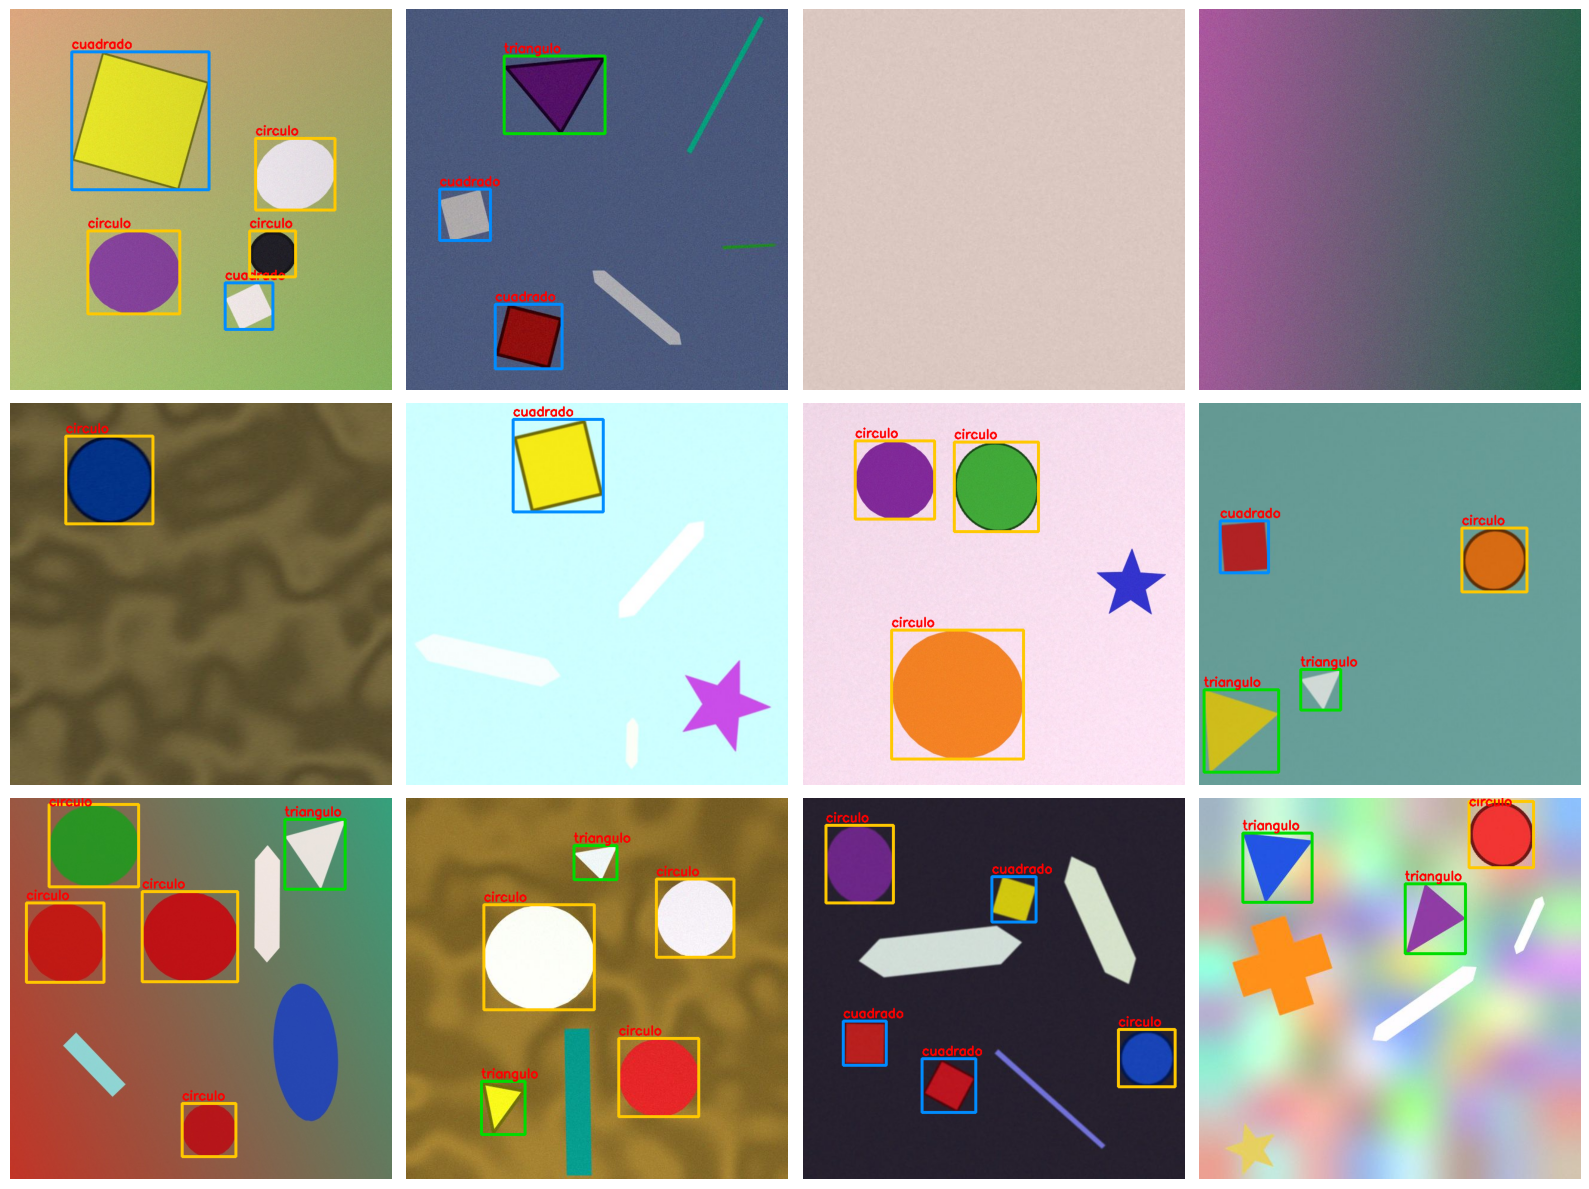

split   imgs    circulo   cuadrado  triangulo   total_objetos   imgs_sin_figuras
train   1260       1138       1119       1094            3351                 154
val      360        315        300        318             933                  46
test     180        173        132        134             439                  27


In [5]:
# Muestras del dataset con sus cajas + distribución por clase (para el informe)
import random, cv2, matplotlib.pyplot as plt   # azar, OpenCV y gráficas
from collections import Counter                 # para contar objetos por clase
from pathlib import Path                        # manejo de rutas
from shapes_utils import CLASSES, BOX_COLORS    # nombres de clases y colores de las cajas

ROOT = Path("data/shapes_yolo")                 # carpeta raíz del dataset

def draw_gt(img_path):                          # dibuja las cajas reales (ground truth) de una imagen
    im = cv2.imread(str(img_path)); h, w = im.shape[:2]    # carga la imagen y toma su alto/ancho
    for line in (ROOT / "labels" / img_path.parent.name / f"{img_path.stem}.txt").read_text().splitlines():   # una línea por figura
        c, x, y, bw, bh = line.split(); c = int(c)                                   # clase, centro (x, y), ancho y alto
        x, y, bw, bh = float(x) * w, float(y) * h, float(bw) * w, float(bh) * h      # de relativo (0-1) a píxeles
        p1, p2 = (int(x - bw / 2), int(y - bh / 2)), (int(x + bw / 2), int(y + bh / 2))   # esquinas de la caja
        cv2.rectangle(im, p1, p2, BOX_COLORS[c], 3)                                  # dibuja la caja
        cv2.putText(im, CLASSES[c], (p1[0], max(p1[1] - 6, 14)), 0, 0.7, (0, 0, 255), 2)   # escribe el nombre de la clase
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)   # pasa a RGB para que matplotlib la muestre bien

random.seed(1)                                   # semilla para que siempre salgan las mismas muestras
muestras = random.sample(sorted((ROOT / "images" / "train").glob("*.jpg")), 12)   # 12 imágenes de train al azar
fig, axs = plt.subplots(3, 4, figsize=(16, 12))  # cuadrícula de 3 filas x 4 columnas
for ax, p in zip(axs.ravel(), muestras):         # una imagen por casilla
    ax.imshow(draw_gt(p)); ax.axis("off")        # la muestra sin ejes
plt.tight_layout(); plt.savefig("docs/muestras_dataset.png", dpi=120); plt.show()   # guarda la figura como evidencia y la muestra

print(f"{'split':6s} {'imgs':>5s} " + " ".join(f"{c:>10s}" for c in CLASSES) + "   total_objetos   imgs_sin_figuras")   # encabezado de la tabla
for split in ["train", "val", "test"]:           # una fila por split
    n_img = len(list((ROOT / "images" / split).glob("*.jpg")))     # cuántas imágenes tiene
    cnt = Counter(int(l.split()[0]) for f in (ROOT / "labels" / split).glob("*.txt") for l in f.read_text().splitlines())   # objetos por clase
    vacias = sum(1 for f in (ROOT / "labels" / split).glob("*.txt") if not f.read_text().strip())   # imágenes sin ninguna figura
    print(f"{split:6s} {n_img:5d} " + " ".join(f"{cnt[i]:10d}" for i in range(len(CLASSES))) + f"   {sum(cnt.values()):13d}   {vacias:17d}")   # imprime la fila

### 2.4 · Probar el detector de color
El color que se muestra en la demo no lo predice YOLO: lo calcula `shapes_utils.py` dentro de la caja. Esta celda lo prueba contra el color real con el que se dibujó cada figura de validación.

In [6]:
# Prueba del detector de color (el que se muestra en la demo) con los datos de validación
import numpy as np, pandas as pd                          # arreglos y tablas
from shapes_utils import PALETTE, color_name, dominant_color   # funciones de color del módulo compartido

meta = pd.read_csv("data/shapes_yolo/meta.csv")           # tabla con el color real de cada figura
val = meta[meta.split == "val"]                           # solo las figuras de validación
cache, preds = {}, []                                     # cache de imágenes y lista de colores predichos
for r in val.itertuples():                                # recorre cada figura
    im = cache.setdefault(r.image, cv2.imread(f"data/shapes_yolo/images/val/{r.image}"))   # carga la imagen (una sola vez)
    preds.append(dominant_color(im[int(r.y1):int(r.y2), int(r.x1):int(r.x2)]))             # color detectado dentro de su caja
val = val.assign(pred=preds)                              # agrega la columna con el color predicho
print(f"Exactitud del detector de color sobre las cajas reales de val: {(val.pred == val.color).mean():.1%} ({len(val)} figuras)")   # % de aciertos
pd.crosstab(val.color, val.pred)                          # tabla: color real (filas) vs color detectado (columnas)

Exactitud del detector de color sobre las cajas reales de val: 100.0% (933 figuras)


pred,amarillo,azul,blanco,morado,naranja,negro,rojo,verde
color,,,,,,,,
amarillo,125,0,0,0,0,0,0,0
azul,0,140,0,0,0,0,0,0
blanco,0,0,111,0,0,0,0,0
morado,0,0,0,114,0,0,0,0
naranja,0,0,0,0,113,0,0,0
negro,0,0,0,0,0,118,0,0
rojo,0,0,0,0,0,0,120,0
verde,0,0,0,0,0,0,0,92


### Ficha del dataset
- **Origen:** generado artificialmente por nosotros con `data/generate_dataset.py` (OpenCV + NumPy); no se descargó de ningún repositorio. Si agregan fotos reales (Parte 3)
- **Clases:** 3 (círculo, cuadrado, triángulo). **Formato:** YOLO (un TXT por imagen con `clase x_centro y_centro ancho alto`, relativo a 0-1).
- **Tamaño:** 640×640 px; el número de imágenes y de objetos por clase y split lo imprime la celda 2.3.
- **Variabilidad:** 5 tipos de fondo, 8 colores, 0 a 5 figuras por imagen, rotación libre, escala 28–115 px, bordes opcionales, luz, ruido y desenfoque.
- **Distractores:** formas sin etiqueta (barras, lámparas, elipses, estrellas, cruces, líneas) y ~12 % de imágenes sin figuras, para reducir falsos positivos.
- **Split:** 70 % train / 20 % val / 10 % test.
- **Imágenes de muestra:** `docs/muestras_dataset.png`.

>Como todo es sintético, las métricas van a salir muy altas. En la Parte 3 se agregan fotos reales de su webcam, que además hacen las métricas más honestas.

---
# PARTE 3 · Fotos reales de su webcam
> **¿Qué hace esta parte?** Corrige el problema típico de entrenar solo con datos sintéticos: el modelo "inventa" figuras en el mundo real (por ejemplo, toma una lámpara del techo por un triángulo). Aquí se agregan fotos reales: unas **sin figuras** (para que aprenda qué NO es una figura) y, si quieren, otras **con figuras** etiquetadas.
>
> **Paso 1 – Capturar (en su PC, no en Colab).** Bajen `capture_frames.py` (celda 3.1) y corran:
> ```
> python capture_frames.py --mode vacio     # SIN figuras: techo, lámparas, paredes, sus caras, la mesa (150-200 fotos)
> python capture_frames.py --mode figuras   # CON figuras dibujadas/impresas/recortadas (60-100 fotos)
> ```
> ESPACIO guarda una foto, `a` enciende/apaga la captura automática (una foto cada 0.8 s), `q` sale.
>
> **Paso 2 – Etiquetar solo las fotos con figuras** en Roboflow (gratis): proyecto *Object Detection*, clases `circulo`, `cuadrado`, `triangulo` (con esos nombres), cajas alrededor de cada figura, y exportar en formato **YOLOv8** (zip). Las fotos de `vacio` **no** se etiquetan.
>
> **Paso 3 – Subir a Colab y mezclar (celdas 3.3-A, B y C).** Se suben por separado: en la **A** el zip de fotos vacías (`vacio.zip`), en la **B** el zip de fotos con figuras etiquetadas (`roboflow_figuras.zip` o su export de Roboflow) y en la **C** se mezclan ambas con el dataset. **Revisen que la A imprima "Fotos vacías encontradas" y la B "Export encontrado: True", ambas con números mayores que 0.**
>
> Si todavía no tienen fotos, pueden saltar a la Parte 4 y volver después (se repite: Parte 2.2 → Parte 3.3 → Parte 4).

### 3.1 · Escribir el script de captura (`capture_frames.py`)
Se usa en el PC con webcam, no en Colab. Aquí solo se escribe el archivo para poder descargarlo.

In [7]:
%%writefile capture_frames.py
"""Captura cuadros de la webcam para reentrenar con datos reales.
Uso (en tu PC):
  python capture_frames.py --mode vacio     # SIN figuras: techo, lámparas, paredes, tu cara, la mesa...
  python capture_frames.py --mode figuras   # CON figuras (dibujadas, impresas o recortadas)
Teclas: ESPACIO guarda un cuadro | a activa/desactiva captura automática | q o ESC salir
Las fotos quedan en mis_fotos/<modo>/ (máximo 640 px de lado).
"""
import argparse  # lee los parámetros de la línea de comandos
import time  # para medir el tiempo entre fotos y nombrar los archivos
from pathlib import Path  # manejo cómodo de rutas

import cv2  # acceso a la webcam y manejo de imágenes


def main():
    ap = argparse.ArgumentParser()  # define los parámetros del script
    ap.add_argument("--mode", choices=["vacio", "figuras"], required=True)  # qué tipo de fotos se van a tomar
    ap.add_argument("--out", default="mis_fotos")  # carpeta base de salida
    ap.add_argument("--cam", type=int, default=0)  # número de la cámara (0 = la del portátil)
    ap.add_argument("--auto", type=float, default=0.8, help="segundos entre fotos en modo automático")  # ritmo del modo automático
    a = ap.parse_args()  # lee lo que escribió el usuario

    out = Path(a.out) / a.mode  # carpeta final: mis_fotos/vacio o mis_fotos/figuras
    out.mkdir(parents=True, exist_ok=True)  # la crea si no existe
    cap = cv2.VideoCapture(a.cam)  # abre la cámara
    if not cap.isOpened():  # si no se pudo abrir (p. ej. otro programa la está usando)
        raise SystemExit("No se pudo abrir la camara.")  # termina con un mensaje claro

    n = len(list(out.glob("*.jpg")))  # fotos que ya había en la carpeta (no se borran)
    auto, last = False, 0.0  # captura automática apagada; instante de la última foto automática
    print(f"Guardando en {out}/  (ya hay {n} fotos)")  # avisa dónde se guarda
    while True:  # ciclo principal: un cuadro de video por vuelta
        ok, frame = cap.read()  # lee un cuadro de la cámara
        if not ok:  # si falla la lectura
            break  # sale del ciclo
        h, w = frame.shape[:2]  # alto y ancho del cuadro
        s = 640 / max(h, w)  # factor para que el lado más largo quede en 640 px
        small = cv2.resize(frame, (int(w * s), int(h * s))) if s < 1 else frame  # reduce solo si es más grande que 640
        now = time.time()  # hora actual en segundos

        guardar = False  # por defecto no se guarda foto automática en esta vuelta
        if auto and now - last >= a.auto:  # si el modo automático está activo y ya pasó el intervalo
            guardar, last = True, now  # toca guardar y se anota la hora
        if guardar:  # si toca guardar
            cv2.imwrite(str(out / f"{a.mode}_{int(now * 1000)}.jpg"), small)  # guarda la foto (nombre = modo + milisegundos)
            n += 1  # suma al contador

        view = frame.copy()  # copia del cuadro para dibujarle el texto sin ensuciar la foto guardada
        msg = f"{a.mode.upper()} | fotos: {n} | auto: {'ON' if auto else 'OFF'}"  # texto de estado
        cv2.rectangle(view, (8, 8), (8 + 12 * len(msg), 40), (0, 0, 0), -1)  # caja negra de fondo
        cv2.putText(view, msg, (14, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv2.LINE_AA)  # texto amarillo
        cv2.imshow("Captura de cuadros", view)  # muestra la ventana

        k = cv2.waitKey(1) & 0xFF  # lee la tecla presionada (espera 1 ms)
        if k in (ord("q"), 27):  # q o ESC
            break  # salir
        if k == ord(" "):  # barra espaciadora
            cv2.imwrite(str(out / f"{a.mode}_{int(now * 1000)}.jpg"), small)  # guarda una foto manual
            n += 1  # suma al contador
        if k == ord("a"):  # tecla a
            auto = not auto  # enciende o apaga el modo automático

    cap.release()  # libera la cámara
    cv2.destroyAllWindows()  # cierra la ventana
    print(f"Listo: {n} fotos en {out}/")  # resumen final


if __name__ == "__main__":  # solo corre main() si se ejecuta el archivo directamente
    main()

Overwriting capture_frames.py


### 3.2 · Escribir el script que mezcla las fotos (`data/add_real_data.py`)
Reparte las fotos reales 70/20/10 en el dataset. Las de **train** se repiten ×5 (son pocas frente a las sintéticas); val y test llevan una sola copia, para que las métricas sean honestas.

In [8]:
%%writefile data/add_real_data.py
"""Mezcla fotos REALES de la webcam con el dataset ya generado (data/shapes_yolo).

  --vacio     carpeta con fotos SIN figuras (se guardan con etiqueta vacía = "aquí no hay nada")
  --roboflow  carpeta del export de Roboflow en formato YOLOv8 (fotos CON figuras ya etiquetadas)
  --repeat    veces que se repite cada foto real en TRAIN (las reales son pocas frente a las sintéticas);
              val y test siempre llevan una sola copia, para que las métricas sean honestas.

Reparte 70/20/10 al azar. IMPORTANTE: generate_dataset.py borra todo al correr; si lo vuelven a
ejecutar, hay que volver a correr este script.
"""
import argparse  # lee los parámetros de la línea de comandos
import random  # para repartir las fotos al azar entre train/val/test
import shutil  # para copiar archivos
import sys  # para poder importar shapes_utils desde la carpeta de arriba
import unicodedata  # para quitar tildes de los nombres de clase
from pathlib import Path  # manejo cómodo de rutas

import yaml  # lee el data.yaml que exporta Roboflow

sys.path.append(str(Path(__file__).resolve().parents[1]))  # agrega la carpeta del proyecto al path de imports
from shapes_utils import CLASSES  # noqa: E402  # nombres de clase del proyecto (circulo, cuadrado, triangulo)

IMG_EXT = {".jpg", ".jpeg", ".png"}  # extensiones de imagen que se aceptan


def norm(name):
    """Normaliza un nombre de clase: sin tildes, en minúscula, y traduce circle/square/triangle."""
    s = unicodedata.normalize("NFD", str(name)).encode("ascii", "ignore").decode().lower().strip()  # quita tildes y pasa a minúscula
    return {"circle": "circulo", "square": "cuadrado", "triangle": "triangulo"}.get(s, s)  # traduce del inglés si hace falta


def split_items(items, rng):
    """Reparte una lista en val (20 %), test (10 %) y train (el resto), al azar."""
    items = items[:]  # copia para no modificar la lista original
    rng.shuffle(items)  # mezcla al azar
    n = len(items)  # cuántas fotos hay
    n_val = max(1, round(n * 0.2)) if n >= 5 else 0  # 20 % para validación (si hay al menos 5 fotos)
    n_test = max(1, round(n * 0.1)) if n >= 5 else 0  # 10 % para test
    return {"val": items[:n_val], "test": items[n_val:n_val + n_test], "train": items[n_val + n_test:]}  # el resto es train


def save(out, split, img, lines, tag, repeat):
    """Copia una foto real (y su TXT de etiquetas) al split indicado; en train la repite `repeat` veces."""
    for k in range(repeat if split == "train" else 1):  # train: varias copias; val/test: una sola
        name = f"real_{tag}_{img.stem}" + (f"_r{k}" if k else "")  # nombre con prefijo real_ (así se distinguen de las sintéticas)
        shutil.copy(img, out / "images" / split / f"{name}{img.suffix.lower()}")  # copia la imagen
        (out / "labels" / split / f"{name}.txt").write_text("\n".join(lines))  # escribe sus etiquetas (vacío si no hay figuras)


def load_roboflow(folder):
    """Devuelve [(imagen, [lineas YOLO con IDs ya convertidos a nuestras clases])]."""
    folder = Path(folder)  # carpeta del export de Roboflow
    names = yaml.safe_load((folder / "data.yaml").read_text())["names"]  # nombres de clase que usó Roboflow
    names = list(names.values()) if isinstance(names, dict) else list(names)  # los pasa a lista (pueden venir como diccionario)
    mapa = {i: CLASSES.index(norm(n)) for i, n in enumerate(names) if norm(n) in CLASSES}  # ID de Roboflow -> ID nuestro
    print("Clases del export de Roboflow:", names, "-> mapa a IDs propios:", mapa)  # muestra la conversión para revisarla
    items = []  # resultado: (imagen, líneas de etiqueta)
    for img in sorted(p for p in folder.rglob("*") if p.suffix.lower() in IMG_EXT and p.parent.name == "images"):  # todas las imágenes del export
        lbl = img.parent.parent / "labels" / f"{img.stem}.txt"  # su archivo de etiquetas
        lines = []  # etiquetas ya convertidas
        if lbl.exists():  # si la foto tiene etiquetas
            for line in lbl.read_text().strip().splitlines():  # recorre cada caja
                parts = line.split()  # separa: clase x y ancho alto
                if len(parts) == 5 and int(parts[0]) in mapa:  # ignora líneas raras y clases que no son las nuestras
                    lines.append(" ".join([str(mapa[int(parts[0])])] + parts[1:]))  # cambia el ID de clase y deja lo demás igual
        items.append((img, lines))  # guarda la foto con sus etiquetas
    return items  # lista lista para repartir en splits


def main():
    ap = argparse.ArgumentParser()  # define los parámetros del script
    ap.add_argument("--data", default="data/shapes_yolo")  # dataset al que se le agregan las fotos
    ap.add_argument("--vacio", default=None)  # carpeta de fotos sin figuras
    ap.add_argument("--roboflow", default=None)  # carpeta del export de Roboflow
    ap.add_argument("--repeat", type=int, default=5)  # cuántas veces se repite cada foto real en train
    ap.add_argument("--seed", type=int, default=42)  # semilla del reparto al azar
    a = ap.parse_args()  # lee lo que escribió el usuario
    out, rng = Path(a.data), random.Random(a.seed)  # carpeta del dataset y generador de azar reproducible

    for f in list((out / "images").rglob("real_*")) + list((out / "labels").rglob("real_*")):  # busca fotos reales de corridas anteriores
        f.unlink()  # limpiar corridas anteriores para no duplicar fotos

    added = {"train": [0, 0], "val": [0, 0], "test": [0, 0]}  # contadores [con figuras, vacías] por split
    if a.vacio and Path(a.vacio).exists():  # si hay fotos sin figuras
        imgs = sorted(p for p in Path(a.vacio).rglob("*") if p.suffix.lower() in IMG_EXT)  # las busca (también dentro de subcarpetas)
        for split, items in split_items([(p, []) for p in imgs], rng).items():  # las reparte en train/val/test
            for img, lines in items:  # cada foto del split
                save(out, split, img, lines, "vacio", a.repeat)  # la copia con etiqueta vacía
                added[split][1] += 1  # cuenta una foto vacía más
    if a.roboflow and Path(a.roboflow).exists():  # si hay fotos con figuras etiquetadas
        for split, items in split_items(load_roboflow(a.roboflow), rng).items():  # las carga y reparte
            for img, lines in items:  # cada foto del split
                save(out, split, img, lines, "figuras", a.repeat)  # la copia con sus etiquetas
                added[split][0] += 1  # cuenta una foto con figuras más

    print("Fotos reales agregadas (originales, sin contar repeticiones en train):")  # resumen
    for s, (f, v) in added.items():  # por cada split
        print(f"  {s:5s} con figuras: {f:3d}   vacias: {v:3d}")  # cuántas fotos de cada tipo se agregaron
    for s in ["train", "val", "test"]:  # totales finales
        print(f"  total {s}: {len(list((out / 'images' / s).iterdir()))} imagenes")  # imágenes totales del split


if __name__ == "__main__":  # solo corre main() si se ejecuta el archivo directamente
    main()

Overwriting data/add_real_data.py


### 3.3 · Subir las fotos reales (por separado) y mezclarlas con el dataset
Se hace en **tres celdas**: **A** sube las fotos *sin figuras* (`vacio.zip`), **B** sube las fotos *con figuras* ya etiquetadas (`roboflow_figuras.zip`) y **C** mezcla ambas con el dataset sintético. A y B son independientes (cualquier orden, y una no borra lo de la otra); **C se corre siempre al final**. Las dos ayudan al entrenamiento: las vacías enseñan qué **no** es una figura y las de figuras enseñan cómo se ve una figura **real** (celular, tablet, su cuarto).


In [9]:
# 3.3-A · Subir SOLO el zip de fotos vacías (sin figuras): vacio.zip
import os, shutil, glob                          # carpetas, copia de archivos y búsqueda por patrón
from google.colab import files                   # selector de archivos de Colab

subidos = files.upload()                         # abre el selector: elijan vacio.zip
shutil.rmtree("mis_fotos", ignore_errors=True)   # borra restos de subidas anteriores (solo las vacías)
os.makedirs("mis_fotos/vacio", exist_ok=True)    # carpeta final donde quedan las fotos
for nombre in subidos:                           # cada archivo subido (Colab puede renombrarlo, p. ej. "vacio (1).zip")
    # Descomprime en una carpeta temporal (comentario arriba: las líneas con ! no admiten comentarios al final)
    !unzip -q -o "{nombre}" -d mis_fotos/_tmp
    for f in glob.glob("mis_fotos/_tmp/**/*.*", recursive=True):    # busca fotos aunque el zip traiga una carpeta adentro
        if f.lower().endswith((".jpg", ".jpeg", ".png")):           # solo imágenes
            shutil.copy(f, os.path.join("mis_fotos/vacio", os.path.basename(f)))   # las deja "planas" en una sola carpeta
shutil.rmtree("mis_fotos/_tmp", ignore_errors=True)                # borra la carpeta temporal
n_vacio = len(os.listdir("mis_fotos/vacio"))     # cuántas fotos quedaron
print("Fotos vacías encontradas:", n_vacio)      # deben ser 145 (o las que hayan tomado)
if n_vacio == 0:                                 # si no hay ninguna, algo salió mal con el zip
    print("OJO: no se encontró ninguna foto. Revisen que el zip sea el de fotos SIN figuras.")


Saving vacio.zip to vacio (1).zip
Fotos vacías encontradas: 145


In [10]:
# 3.3-B · Subir SOLO el zip de fotos con figuras (ya etiquetadas): roboflow_figuras.zip
import os, shutil, glob                          # carpetas, copia de archivos y búsqueda por patrón
from google.colab import files                   # selector de archivos de Colab

subidos = files.upload()                         # abre el selector: elijan roboflow_figuras.zip (o su export de Roboflow)
shutil.rmtree("roboflow_export", ignore_errors=True)   # borra restos de subidas anteriores (solo las de figuras)
for nombre in subidos:                           # cada archivo subido
    # Descomprime el export tal cual (comentario arriba: las líneas con ! no admiten comentarios al final)
    !unzip -q -o "{nombre}" -d roboflow_export
yamls = glob.glob("roboflow_export/**/data.yaml", recursive=True)    # el data.yaml dice los nombres de las clases
n_figs = len(glob.glob("roboflow_export/**/images/*.*", recursive=True))   # fotos con figuras que llegaron
print("Export encontrado (data.yaml):", bool(yamls))   # debe decir True
print("Fotos con figuras:", n_figs)                    # deben ser 86 con el zip que les di
if not yamls:                                    # sin data.yaml no se sabe qué clase es cuál
    print("OJO: falta data.yaml dentro del zip. Si lo exportaron de Roboflow, elijan el formato YOLOv8.")


Saving roboflow_figuras.zip to roboflow_figuras (1).zip
Export encontrado (data.yaml): True
Fotos con figuras: 110


In [11]:
# 3.3-C · Mezclar lo subido en A y/o B con el dataset sintético (correr siempre al final)
import os, glob                                  # carpetas y búsqueda por patrón

vac = "mis_fotos/vacio" if os.path.isdir("mis_fotos/vacio") and os.listdir("mis_fotos/vacio") else ""   # carpeta de vacías (si hay)
yamls = glob.glob("roboflow_export/**/data.yaml", recursive=True)           # busca el data.yaml del export
rob = os.path.dirname(yamls[0]) if yamls else ""                            # carpeta del export (donde está el data.yaml)
if not vac and not rob:                          # si no hay nada que mezclar, mejor parar aquí
    raise SystemExit("No hay fotos reales: corran antes la celda A y/o la B.")
args = (f"--vacio {vac} " if vac else "") + (f"--roboflow {rob} " if rob else "")   # arma los parámetros del script
print("Mezclando ->", args)                      # muestra qué se está usando
!python data/add_real_data.py {args}--repeat 5


Mezclando -> --vacio mis_fotos/vacio --roboflow roboflow_export 
Clases del export de Roboflow: ['circulo', 'cuadrado', 'triangulo'] -> mapa a IDs propios: {0: 0, 1: 1, 2: 2}
Fotos reales agregadas (originales, sin contar repeticiones en train):
  train con figuras:  77   vacias: 102
  val   con figuras:  22   vacias:  29
  test  con figuras:  11   vacias:  14
  total train: 2155 imagenes
  total val: 411 imagenes
  total test: 205 imagenes


---
# PARTE 4 · Entrenamiento
> **¿Qué hace esta parte?** Entrena YOLOv8 con *transfer learning* (parte de pesos ya aprendidos y los ajusta a nuestras 3 figuras), con `imgsz=640`, hasta `EPOCHS` épocas y **early stopping** (se detiene si no mejora en 10 épocas). Al terminar copia los mejores pesos a `models/best.pt`.
>
> **Pasos:** 4.1 escribir `train.py` → 4.2 entrenar → 4.3 ver curvas → 4.4 revisar si el entrenamiento **se saturó**.

### 4.1 · Escribir `train.py`

In [12]:
%%writefile train.py
"""Entrena YOLO (>= v8) sobre el dataset de figuras y guarda los mejores pesos en models/best.pt.
Uso: python train.py --epochs 50 --batch 16
"""
import argparse  # lee los parámetros de la línea de comandos
import shutil  # para copiar el archivo de pesos final
from pathlib import Path  # manejo cómodo de rutas

import torch  # PyTorch: se usa aquí solo para saber si hay GPU
from ultralytics import YOLO  # librería que contiene YOLOv8 y posteriores


def main():
    ap = argparse.ArgumentParser()  # define los parámetros del script
    ap.add_argument("--data", default="data/shapes_yolo/data.yaml")  # archivo que dice dónde están los datos
    ap.add_argument("--model", default="yolov8n.pt", help="modelo base (>= v8): yolov8n/s/m, yolo11n...")  # modelo de partida
    ap.add_argument("--epochs", type=int, default=50)  # máximo de épocas (el enunciado pide 30-50)
    ap.add_argument("--imgsz", type=int, default=640)  # tamaño de imagen de entrenamiento (el enunciado pide 640)
    ap.add_argument("--batch", type=int, default=16, help="bajar a 8 si la GPU se queda sin memoria")  # imágenes por paso
    ap.add_argument("--patience", type=int, default=10, help="early stopping (épocas sin mejorar)")  # paciencia del early stopping
    a = ap.parse_args()  # lee lo que escribió el usuario

    device = 0 if torch.cuda.is_available() else "cpu"  # usa la GPU 0 si existe; si no, la CPU
    print(f"Dispositivo: {device}")  # muestra cuál se está usando

    model = YOLO(a.model)  # parte de pesos preentrenados (transfer learning)
    model.train(  # lanza el entrenamiento
        data=str(Path(a.data).resolve()), epochs=a.epochs, imgsz=a.imgsz, batch=a.batch,  # datos y parámetros principales
        patience=a.patience,            # early stopping activado
        device=device, seed=42, plots=True,  # dispositivo, semilla fija y gráficas (curvas, matriz de confusión)
        project=str(Path("runs").resolve()), name="shapes", exist_ok=True,  # guarda todo en runs/shapes (sobrescribe)
    )

    save_dir = Path(model.trainer.save_dir)  # carpeta donde Ultralytics dejó los resultados
    Path("models").mkdir(exist_ok=True)  # crea la carpeta models/ si no existe
    shutil.copy(save_dir / "weights" / "best.pt", "models/best.pt")  # copia los mejores pesos a models/best.pt
    print(f"Pesos finales guardados en models/best.pt (corrida: {save_dir})")  # confirma dónde quedaron


if __name__ == "__main__":  # solo corre main() si se ejecuta el archivo directamente
    main()

Overwriting train.py


### 4.2 · Entrenar
Demora unos 10-20 minutos con GPU T4. Al final debe decir "Pesos finales guardados en models/best.pt".

In [13]:
# Entrena con los parámetros de la configuración y early stopping de 10 épocas
!python train.py --model {BASE_MODEL} --epochs {EPOCHS} --batch {BATCH} --patience 10

Dispositivo: 0
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/shapes_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shapes, nbs=64, nms=None, opset=None, o

### 4.3 · Curvas de entrenamiento
Muestra cómo bajaron las pérdidas (loss) y cómo subieron precisión, recall y mAP en cada época.

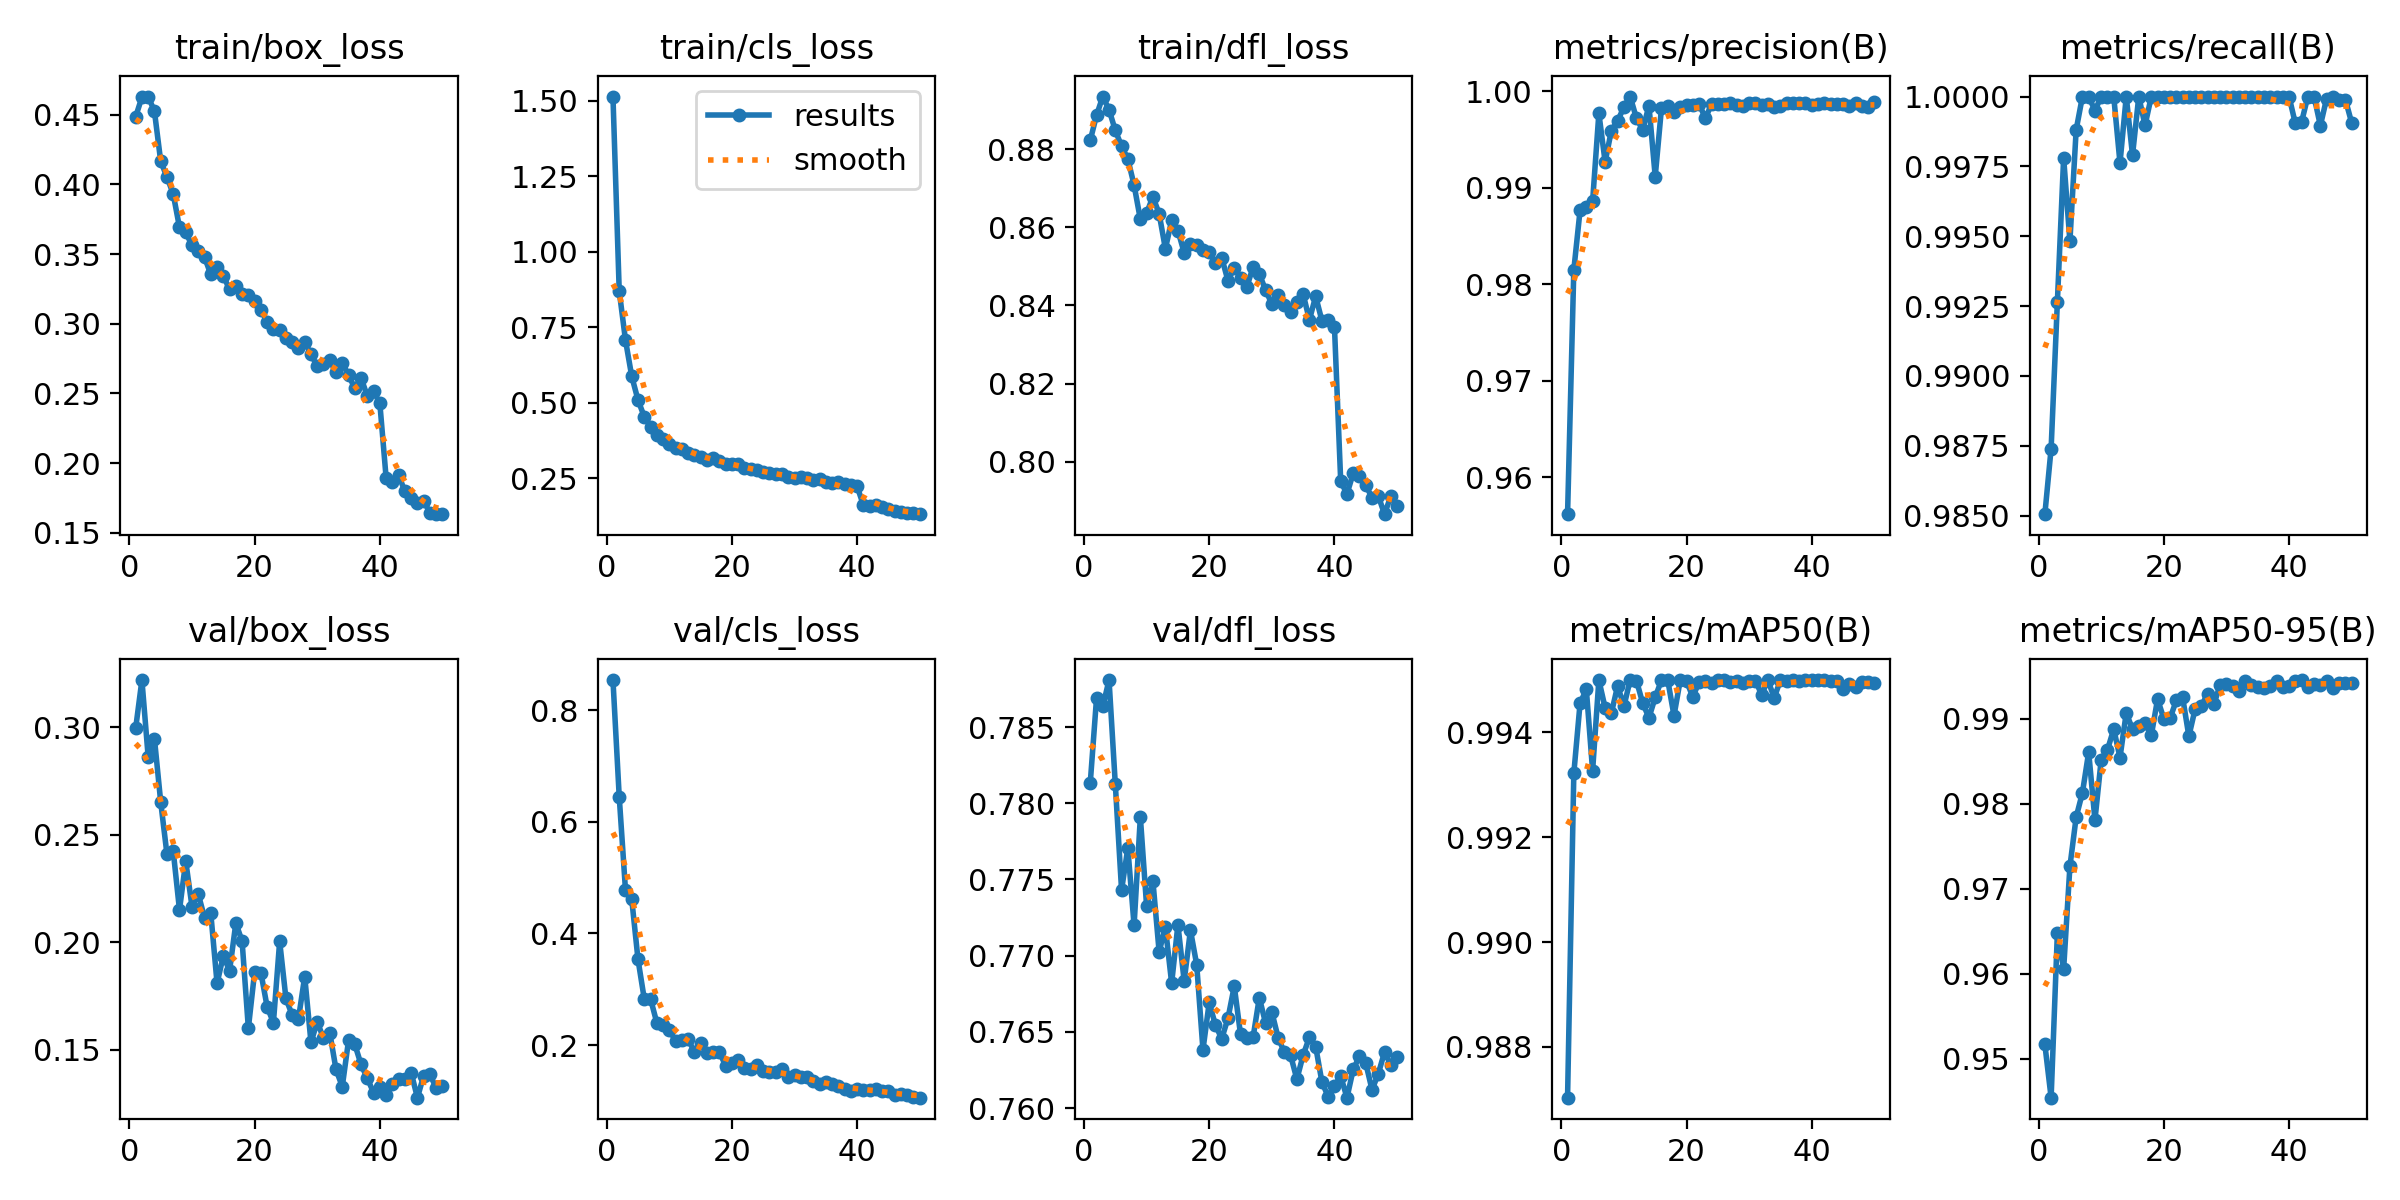

In [14]:
# Curvas de entrenamiento (loss, precisión, recall, mAP por época)
from IPython.display import Image, display   # para mostrar la imagen en el notebook
from pathlib import Path                     # manejo de rutas
curvas = sorted(Path("runs").rglob("results.png"), key=lambda p: p.stat().st_mtime)[-1]   # results.png más reciente
display(Image(filename=str(curvas)))         # la muestra

### 4.4 · ¿Se saturó el entrenamiento? (diagnóstico)
> **¿Qué hace esta celda?** Lee `results.csv` y responde dos preguntas:
> 1. **¿En qué época el mAP@0.5 ya llegó a ~0.99?** El tope práctico de Ultralytics es ≈0.995. Si se alcanza en las primeras épocas, la validación está **saturada**: el problema es tan fácil para ese conjunto de datos que las métricas ya no distinguen entre un modelo bueno y uno excelente.
> 2. **¿Hay sobreajuste?** Compara la pérdida de entrenamiento con la de validación: si la de validación es mucho mayor, el modelo memorizó.
>
> Ojo: la validación es sintética igual que el entrenamiento, así que **no detecta** el desfase con el mundo real. Para eso sirve la celda 5.4.

In [15]:
# Diagnóstico de saturación y sobreajuste a partir de results.csv
import pandas as pd                                                       # lectura de la tabla de resultados
from pathlib import Path                                                  # manejo de rutas
csv = sorted(Path("runs").rglob("results.csv"), key=lambda p: p.stat().st_mtime)[-1]   # results.csv más reciente
res = pd.read_csv(csv)                                                    # una fila por época
res.columns = res.columns.str.strip()                                     # quita espacios en los nombres de columnas
map50 = res["metrics/mAP50(B)"]                                           # mAP@0.5 de validación en cada época
map5095 = res["metrics/mAP50-95(B)"]                                      # mAP@0.5:0.95 (más exigente) en cada época
n_ep = int(res["epoch"].max())                                            # épocas realmente entrenadas
mejor = int(res.loc[map5095.idxmax(), "epoch"])                           # época con el mejor mAP@0.5:0.95
primera = int(res.loc[map50 >= 0.99, "epoch"].iloc[0]) if (map50 >= 0.99).any() else None   # primera época con mAP@0.5 >= 0.99
print(f"Épocas entrenadas: {n_ep} de {EPOCHS} (early stopping)" if n_ep < EPOCHS else f"Épocas entrenadas: {n_ep} de {EPOCHS}")   # si paró antes
print(f"Mejor época (mAP@0.5:0.95): {mejor} | mAP@0.5 final: {map50.iloc[-1]:.3f} | mAP@0.5:0.95 final: {map5095.iloc[-1]:.3f}")   # resumen
if primera is not None:                                                   # si llegó a 0.99
    print(f"El mAP@0.5 llegó a 0.99 en la época {primera}.")              # en qué época
    if primera <= 5:                                                      # si fue muy pronto
        print("  -> Validación SATURADA: el tope de la métrica se alcanzó casi de inmediato; no distingue entre un modelo bueno y uno excelente.")   # aviso
tr, va = res["train/box_loss"].iloc[-1], res["val/box_loss"].iloc[-1]     # pérdida de cajas al final: entrenamiento vs validación
print(f"box_loss final: train={tr:.3f} | val={va:.3f} | brecha val/train = {va / tr:.2f}x")   # compara ambas
print("  -> Sin sobreajuste visible (las pérdidas son parecidas)." if va / tr < 1.3 else "  -> Posible sobreajuste: la pérdida de validación es bastante mayor que la de entrenamiento.")   # veredicto

Épocas entrenadas: 50 de 50
Mejor época (mAP@0.5:0.95): 42 | mAP@0.5 final: 0.995 | mAP@0.5:0.95 final: 0.994
El mAP@0.5 llegó a 0.99 en la época 2.
  -> Validación SATURADA: el tope de la métrica se alcanzó casi de inmediato; no distingue entre un modelo bueno y uno excelente.
box_loss final: train=0.163 | val=0.133 | brecha val/train = 0.82x
  -> Sin sobreajuste visible (las pérdidas son parecidas).


---
# PARTE 5 · Validación y métricas
> **¿Qué hace esta parte?** Mide qué tan bueno es el modelo con datos que no usó para entrenar. Reporta **mAP@0.5, precisión, recall, matriz de confusión por clase** y el **Acc_val** que pide el enunciado: una detección es correcta si empareja un Ground Truth con IoU ≥ 0.5 **y** clase correcta.
> `Acc_val = TP / (TP + FP + FN)` (con umbral de confianza 0.25). Esa fórmula es una interpretación nuestra de la definición, así que escríbanla tal cual en el informe.
> Guarda todo en `models/metrics.json`; de ahí lee la demo el número del overlay.
>
> **Pasos:** 5.1 escribir `evaluate.py` → 5.2 ejecutar y ver la matriz de confusión → 5.3 ver predicciones de ejemplo → 5.4 comparar Acc_val en fotos reales vs sintéticas.

### 5.1 · Escribir `evaluate.py`

In [16]:
%%writefile evaluate.py
"""Reproduce las métricas: mAP@0.5, precisión, recall, matriz de confusión y Accuracy_val.
Escribe models/metrics.json (la demo en tiempo real lee de ahí el Acc_val).
Uso: python evaluate.py
"""
import argparse  # lee los parámetros de la línea de comandos
import json  # para guardar las métricas en models/metrics.json
from pathlib import Path  # manejo cómodo de rutas

import cv2  # lectura de imágenes
import numpy as np  # cálculo con arreglos

from shapes_utils import CLASSES, iou_xyxy  # nombres de clase y cálculo de IoU


def read_gt(label_path, w, h):
    """Lee un TXT YOLO y devuelve [(clase, (x1,y1,x2,y2) en píxeles)]."""
    gts = []  # lista de "ground truth" (las cajas reales)
    if label_path.exists():  # si la imagen tiene archivo de etiquetas
        for line in label_path.read_text().strip().splitlines():  # una línea por figura
            c, x, y, bw, bh = line.split()  # clase, centro x, centro y, ancho, alto (relativos 0-1)
            x, y, bw, bh = float(x) * w, float(y) * h, float(bw) * w, float(bh) * h  # pasa a píxeles
            gts.append((int(c), (x - bw / 2, y - bh / 2, x + bw / 2, y + bh / 2)))  # de centro+tamaño a esquinas
    return gts  # lista vacía si la imagen no tiene figuras


def acc_val(model, img_dir, lbl_dir, conf=0.25, iou_thr=0.5):
    """Accuracy_val según el enunciado: una detección es correcta si empareja un Ground Truth
    con IoU >= 0.5 y clase correcta.
        TP = detecciones correctas
        FP = detecciones que no empatan con ningún GT (mal ubicadas, clase incorrecta o duplicadas)
        FN = GT sin detección correcta
        Acc_val = TP / (TP + FP + FN)
    """
    tp = fp = fn = 0  # contadores de aciertos, falsos positivos y falsos negativos
    paths = sorted(p for p in Path(img_dir).iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})  # todas las imágenes del split
    for p in paths:  # recorre imagen por imagen
        img = cv2.imread(str(p))  # carga la imagen
        h, w = img.shape[:2]  # su alto y ancho
        gts = read_gt(Path(lbl_dir) / f"{p.stem}.txt", w, h)  # cajas reales de esta imagen
        res = model.predict(img, conf=conf, verbose=False)[0]  # detecciones del modelo (solo las de confianza >= conf)
        dets = []  # detecciones como lista simple
        if res.boxes is not None and len(res.boxes) > 0:  # si el modelo detectó algo
            dets = list(zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy().astype(int),  # caja y clase
                            res.boxes.conf.cpu().numpy()))  # y confianza de cada detección
        dets.sort(key=lambda d: -d[2])  # primero las de mayor confianza
        matched = set()  # cajas reales que ya fueron emparejadas
        for box, c, _ in dets:  # revisa cada detección
            best, best_j = 0.0, -1  # mejor IoU encontrado y con qué caja real
            for j, (gc, gb) in enumerate(gts):  # compara contra cada caja real
                if j in matched or gc != c:  # salta las ya usadas y las de otra clase
                    continue
                v = iou_xyxy(box, gb)  # qué tanto se solapan
                if v > best:  # si es el mejor hasta ahora
                    best, best_j = v, j  # lo guarda
            if best >= iou_thr:  # solapa lo suficiente (IoU >= 0.5) y con la clase correcta
                tp += 1  # acierto
                matched.add(best_j)  # esa caja real ya no se puede usar otra vez
            else:  # no empata con ninguna caja real
                fp += 1  # falso positivo (inventó algo, se equivocó de clase o duplicó)
        fn += len(gts) - len(matched)  # cajas reales sin detección correcta = falsos negativos
    return {"tp": tp, "fp": fp, "fn": fn, "acc_val": tp / max(tp + fp + fn, 1),  # resultados y la fórmula TP/(TP+FP+FN)
            "n_images": len(paths)}  # cuántas imágenes se evaluaron


def main():
    from ultralytics import YOLO  # se importa aquí para que acc_val() se pueda probar sin ultralytics

    ap = argparse.ArgumentParser()  # define los parámetros del script
    ap.add_argument("--weights", default="models/best.pt")  # pesos a evaluar
    ap.add_argument("--data", default="data/shapes_yolo/data.yaml")  # dataset a usar
    ap.add_argument("--conf", type=float, default=0.25, help="umbral de confianza para Acc_val")  # umbral para contar detecciones
    a = ap.parse_args()  # lee lo que escribió el usuario

    model = YOLO(a.weights)  # carga el modelo entrenado
    root = Path(a.data).parent  # carpeta raíz del dataset
    out = {}  # aquí se acumulan las métricas
    for split in ["val", "test"]:  # evalúa validación y test
        m = model.val(data=str(Path(a.data).resolve()), split=split, imgsz=640, conf=0.001,  # métricas oficiales de Ultralytics
                      plots=True, verbose=False, project=str(Path("runs").resolve()),  # genera matriz de confusión y curvas
                      name=f"eval_{split}", exist_ok=True)  # en runs/eval_val y runs/eval_test
        per_class = {}  # métricas separadas por clase
        for k, ci in enumerate(m.box.ap_class_index):  # recorre las clases presentes
            per_class[CLASSES[int(ci)]] = {"precision": float(m.box.p[k]), "recall": float(m.box.r[k]),  # precisión y recall de la clase
                                           "ap50": float(m.box.ap50[k])}  # AP@0.5 de la clase
        acc = acc_val(model, root / "images" / split, root / "labels" / split, conf=a.conf)  # Accuracy_val según el enunciado
        out[split] = {"map50": float(m.box.map50), "precision": float(m.box.mp), "recall": float(m.box.mr),  # métricas globales
                      "per_class": per_class, "confusion_matrix_dir": str(m.save_dir), **acc}  # por clase + carpeta de la matriz + Acc_val
        print(f"\n== {split.upper()} ==  mAP@0.5={m.box.map50:.3f}  P={m.box.mp:.3f}  R={m.box.mr:.3f}  "  # resumen del split
              f"Acc_val={acc['acc_val'] * 100:.1f}%  (TP={acc['tp']} FP={acc['fp']} FN={acc['fn']})")  # con aciertos y errores
        for c, d in per_class.items():  # detalle por clase
            print(f"   {c:10s} P={d['precision']:.3f}  R={d['recall']:.3f}  AP50={d['ap50']:.3f}")  # una línea por clase

    out["acc_val"] = out["val"]["acc_val"] * 100  # lo que muestra la demo (en %)
    Path("models").mkdir(exist_ok=True)  # crea models/ si no existe
    Path("models/metrics.json").write_text(json.dumps(out, indent=2))  # guarda todas las métricas
    print("\nGuardado en models/metrics.json")  # confirma


if __name__ == "__main__":  # solo corre main() si se ejecuta el archivo directamente
    main()

Overwriting evaluate.py


### 5.2 · Calcular las métricas y ver la matriz de confusión
Imprime las líneas `== VAL ==` y `== TEST ==` (guárdenlas para el informe) y muestra la matriz de confusión absoluta y normalizada de validación.

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1498.1±431.3 MB/s, size: 32.8 KB)
val: Scanning /content/data/shapes_yolo/labels/val.cache... 411 images, 75 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 411/411 82.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.5it/s 5.7s
                   all        411        963      0.999      0.999      0.995      0.994
Speed: 1.6ms preprocess, 5.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/eval_val

== VAL ==  mAP@0.5=0.995  P=0.999  R=0.999  Acc_val=99.7%  (TP=963 FP=3 FN=0)
   circulo    P=1.000  R=0.997  AP50=0.995
   cuadrado   P=0.997  R=1.000  AP50=0.995
   triangulo  P=1.000  R=1.000  AP50=0.995
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Te

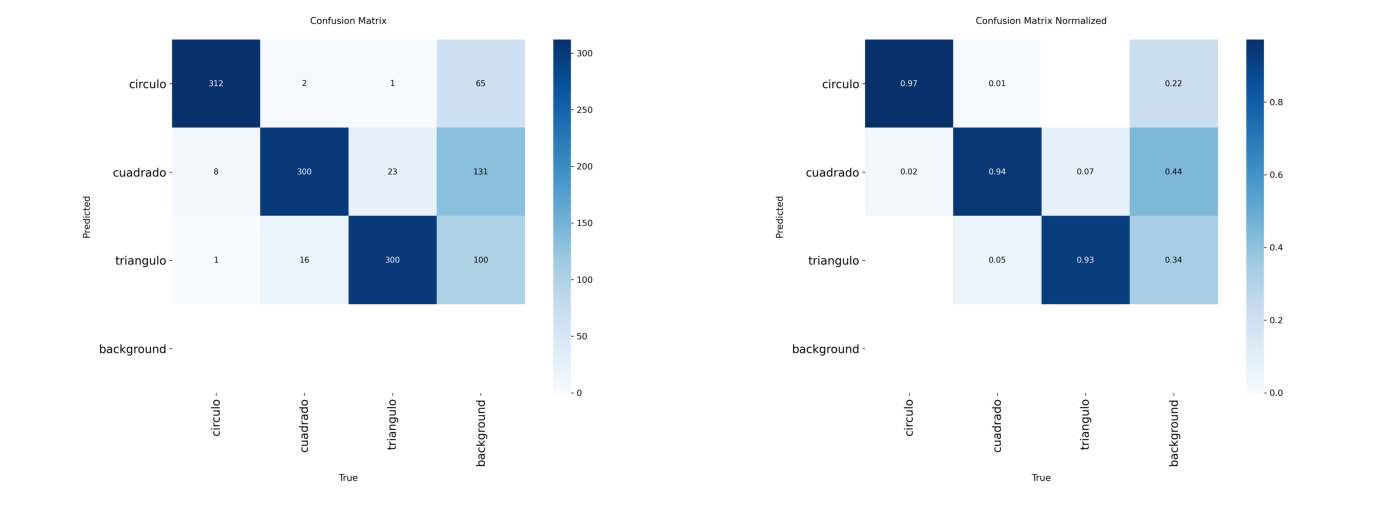

In [17]:
# Calcula mAP@0.5, precisión, recall y Acc_val en val y test, y guarda models/metrics.json
!python evaluate.py

# Matrices de confusión (absoluta y normalizada) sobre validación
import matplotlib.pyplot as plt                                           # gráficas
from pathlib import Path                                                  # manejo de rutas
carpeta = sorted(Path("runs").rglob("eval_val"), key=lambda p: p.stat().st_mtime)[-1]   # carpeta de la última evaluación de val
fig, axs = plt.subplots(1, 2, figsize=(14, 6))                            # dos imágenes lado a lado
for ax, nombre in zip(axs, ["confusion_matrix.png", "confusion_matrix_normalized.png"]):   # absoluta y normalizada
    ax.imshow(plt.imread(carpeta / nombre)); ax.axis("off")               # la muestra sin ejes
plt.tight_layout(); plt.savefig("docs/matriz_confusion_val.png", dpi=120); plt.show()   # guarda como evidencia y muestra

### 5.3 · Predicciones de ejemplo sobre test
Muestra 6 imágenes de test tal como las vería la demo: caja, clase, color, confianza y `Acc_val` fijo arriba.

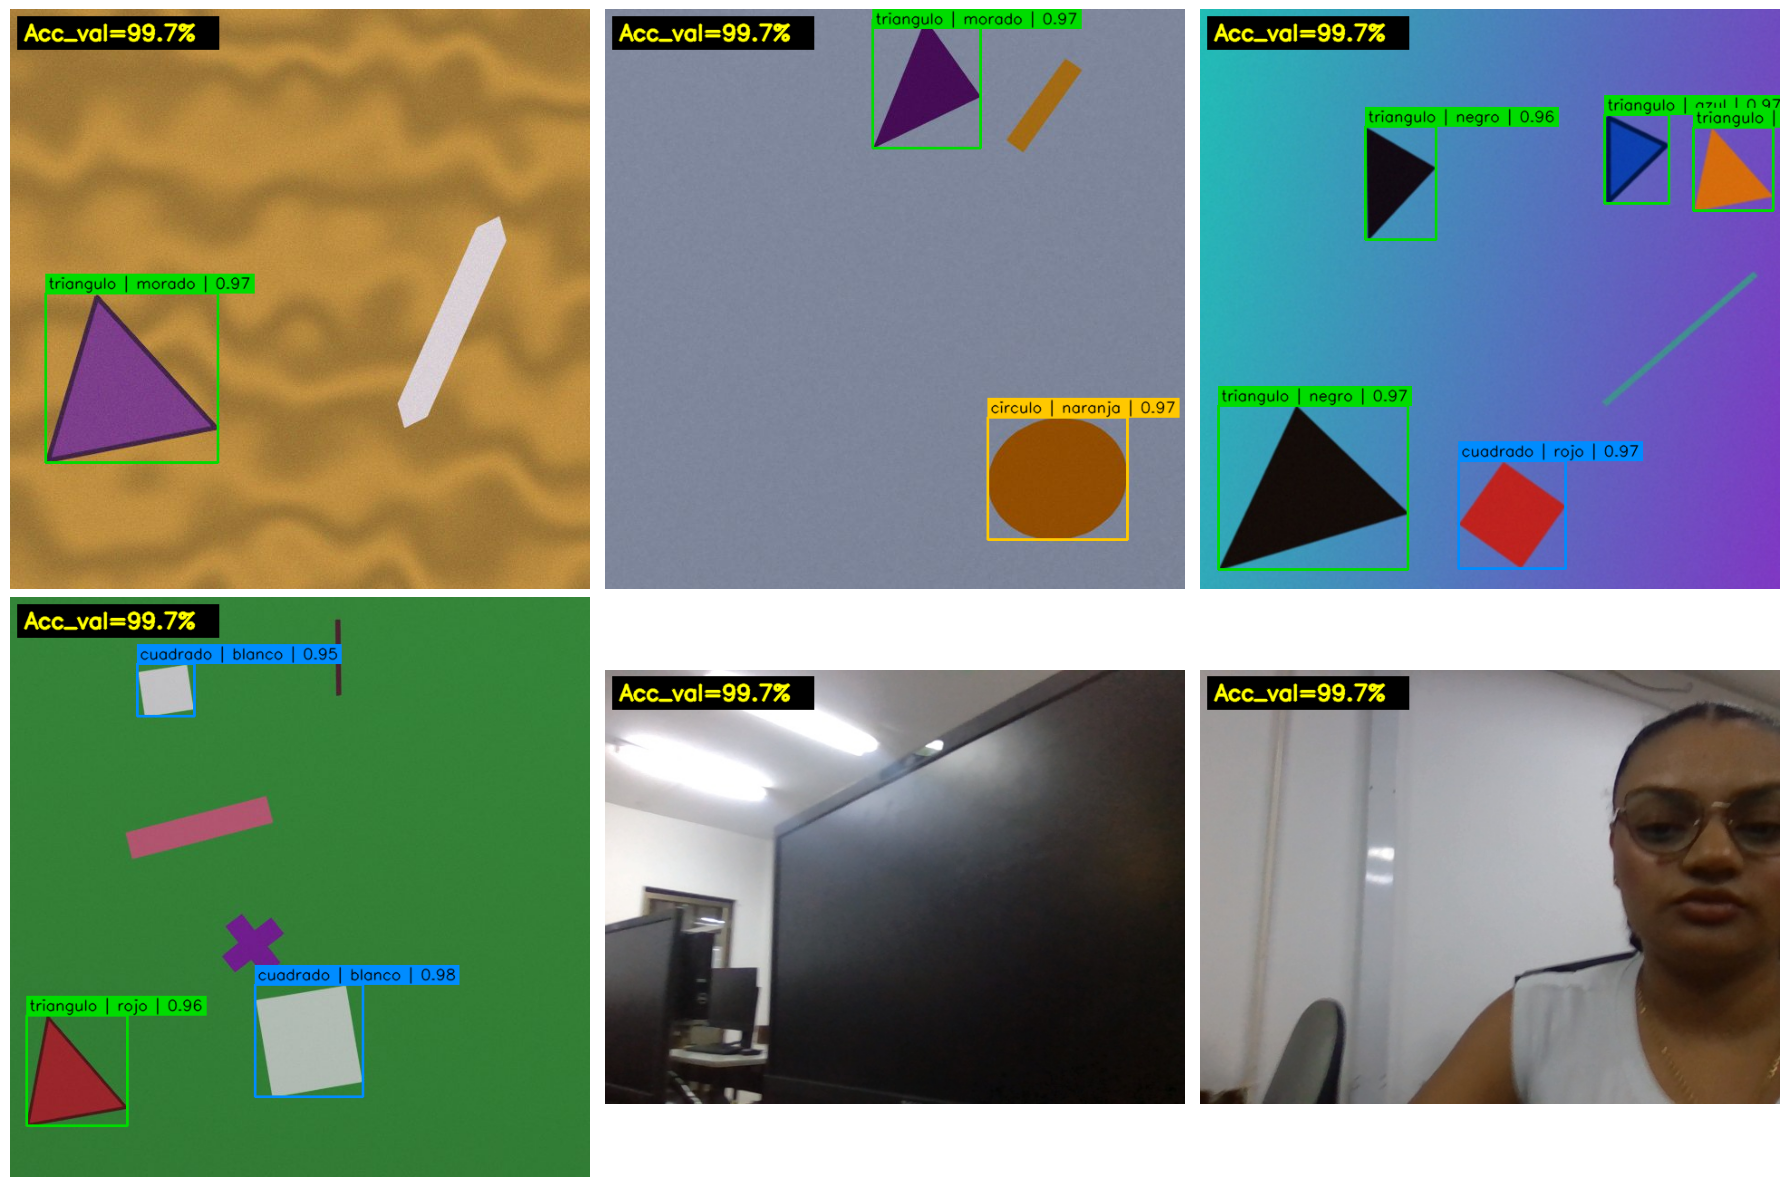

In [18]:
# Predicciones del modelo sobre imágenes de test (bbox + clase + color + confianza + Acc_val)
import json, random, cv2                       # lectura de metrics.json, azar y OpenCV
import matplotlib.pyplot as plt                # gráficas
from pathlib import Path                       # manejo de rutas
from ultralytics import YOLO                   # carga del modelo
from shapes_utils import annotate              # dibuja caja, etiqueta y overlay

ROOT = Path("data/shapes_yolo")                # carpeta raíz del dataset
modelo = YOLO("models/best.pt")                # carga los mejores pesos
acc = json.load(open("models/metrics.json"))["acc_val"]   # Acc_val de validación (en %)
random.seed(7)                                 # semilla para que siempre salgan las mismas imágenes
tests = random.sample(sorted((ROOT / "images" / "test").glob("*.jpg")), 6)   # 6 imágenes de test al azar
fig, axs = plt.subplots(2, 3, figsize=(18, 12))   # cuadrícula de 2 x 3
for ax, p in zip(axs.ravel(), tests):          # una imagen por casilla
    frame = cv2.imread(str(p))                 # carga la imagen
    res = modelo.predict(frame, conf=0.5, verbose=False)[0]   # detecta con umbral de confianza 0.5
    ax.imshow(cv2.cvtColor(annotate(frame, res, acc), cv2.COLOR_BGR2RGB)); ax.axis("off")   # dibuja y muestra
plt.tight_layout(); plt.savefig("docs/predicciones_test.png", dpi=120); plt.show()   # guarda como evidencia y muestra

### 5.4 · Acc_val en fotos reales vs sintéticas (diagnóstico)
> **¿Qué hace esta celda?** Separa la validación en dos grupos y calcula el Acc_val de cada uno: las imágenes **sintéticas** y las **fotos reales** que agregaron en la Parte 3 (las que empiezan por `real_`). Si el Acc_val sintético es ~100 % y el de fotos reales es menor, esa diferencia es el **desfase entre lo sintético y el mundo real**: es el número honesto para el informe y la presentación.
> **Cómo leerlo:** si las fotos reales son solo de `vacio` (sin figuras), no hay figuras que acertar, así que lo que importa es **FP = 0** (ninguna falsa detección, por ejemplo en las lámparas). Cada FP es una figura inventada.
> Si no agregaron fotos reales, la celda lo avisa y no calcula nada.

In [19]:
# Acc_val separado: validación sintética vs fotos reales (real_*)
import shutil                                   # copia de archivos
from pathlib import Path                        # manejo de rutas
from ultralytics import YOLO                    # carga del modelo
from evaluate import acc_val                    # misma fórmula de Acc_val del enunciado

ROOT = Path("data/shapes_yolo")                 # carpeta raíz del dataset
modelo = YOLO("models/best.pt")                 # carga los mejores pesos
grupos = {"sintéticas": [], "reales": []}       # nombres de imagen de cada grupo
for p in sorted((ROOT / "images" / "val").glob("*.*")):   # recorre la validación
    grupos["reales" if p.name.startswith("real_") else "sintéticas"].append(p)   # las reales empiezan por real_

if not grupos["reales"]:                        # si no se agregaron fotos reales
    print("No hay fotos reales en validación: hagan primero la Parte 3 (celda 3.3) y reentrenen.")   # aviso
else:                                           # si las hay, calcula cada grupo por separado
    for nombre, imgs in grupos.items():         # sintéticas y reales
        carpeta = Path("data/val_" + nombre)    # carpeta temporal solo para este grupo
        shutil.rmtree(carpeta, ignore_errors=True)                       # la limpia si existía
        (carpeta / "images").mkdir(parents=True); (carpeta / "labels").mkdir(parents=True)   # crea images/ y labels/
        for p in imgs:                          # copia sus imágenes y etiquetas
            shutil.copy(p, carpeta / "images" / p.name)                  # la imagen
            shutil.copy(ROOT / "labels" / "val" / f"{p.stem}.txt", carpeta / "labels" / f"{p.stem}.txt")   # su TXT
        r = acc_val(modelo, carpeta / "images", carpeta / "labels", conf=0.25)   # Acc_val del grupo
        sin_figuras = (r["tp"] + r["fn"]) == 0                          # True si el grupo solo tiene fotos sin figuras
        acc_txt = "  n/a " if (r["tp"] + r["fp"] + r["fn"]) == 0 else f"{r['acc_val'] * 100:5.1f}%"   # sin figuras ni errores no hay qué medir
        nota = "  <- solo fotos sin figuras: lo ideal es FP=0 (ninguna falsa detección)" if sin_figuras else ""   # cómo leerlo
        print(f"{nombre:11s} imgs={r['n_images']:4d}  Acc_val={acc_txt}  (TP={r['tp']} FP={r['fp']} FN={r['fn']}){nota}")   # resultado

sintéticas  imgs= 360  Acc_val=100.0%  (TP=933 FP=0 FN=0)
reales      imgs=  51  Acc_val= 90.9%  (TP=30 FP=3 FN=0)


---
# PARTE 6 · Demo en tiempo real
> **¿Qué hace esta parte?** Escribe `demo_webcam.py`, el programa que abre la webcam y muestra **al mismo tiempo** la bounding box, la clase, el color, la confianza y el overlay fijo `Acc_val=XX%` (leído de `models/metrics.json`).
> El parámetro `--conf` (por defecto 0.96) descarta todo lo que el modelo detecte con menos confianza: sube para evitar falsos positivos, baja si deja de detectar figuras reales.
>
> **En local** (para la presentación y el video): descarguen `models/best.pt`, `models/metrics.json`, `shapes_utils.py` y `demo_webcam.py` (Parte 8), instalen `pip install ultralytics` y corran:
> ```
> python demo_webcam.py                 # q o ESC para salir, s para captura
> python demo_webcam.py --save demo.mp4 # graba el video de evidencia
> python demo_webcam.py --conf 0.6      # umbral más bajo
> ```
> **En Colab** no hay webcam, así que la celda 6.2 prueba el mismo script con un clip hecho de imágenes de test.

### 6.1 · Escribir `demo_webcam.py`

In [20]:
%%writefile demo_webcam.py
"""Demo en tiempo real: bbox + clase + color + confianza + overlay fijo Acc_val.
Uso:
  python demo_webcam.py                       # webcam 0 (conf=0.96 por defecto)
  python demo_webcam.py --conf 0.6            # umbral más bajo (detecta más, con más riesgo de falsos positivos)
  python demo_webcam.py --cam 1               # otra cámara
  python demo_webcam.py --save demo.mp4       # además graba el video
  python demo_webcam.py --source video.mp4 --no-show --save salida.mp4   # sin ventana (p. ej. Colab)
Teclas: q / ESC salir, s captura de pantalla.
"""
import argparse  # lee los parámetros de la línea de comandos
import json  # para leer el Acc_val guardado en metrics.json
import time  # para calcular los FPS y nombrar las capturas
from pathlib import Path  # manejo cómodo de rutas

import cv2  # webcam, ventana y grabación de video
from ultralytics import YOLO  # carga del modelo entrenado

from shapes_utils import annotate  # dibuja bbox, etiqueta y overlay Acc_val


def main():
    ap = argparse.ArgumentParser()  # define los parámetros del script
    ap.add_argument("--weights", default="models/best.pt")  # pesos del modelo
    ap.add_argument("--metrics", default="models/metrics.json")  # de aquí se lee el Acc_val del overlay
    ap.add_argument("--cam", type=int, default=0)  # número de la cámara (0 = la del portátil)
    ap.add_argument("--source", default=None, help="archivo de video en vez de webcam")  # permite probar con un video
    ap.add_argument("--conf", type=float, default=0.7, help="umbral de confianza: se ignora todo lo que quede por debajo")  # filtro de falsas detecciones
    ap.add_argument("--save", default=None, help="ruta del mp4 de salida")  # si se da, graba el video
    ap.add_argument("--no-show", action="store_true")  # no abre ventana (útil en Colab)
    a = ap.parse_args()  # lee lo que escribió el usuario

    acc = None  # Acc_val a mostrar (si no hay archivo, se muestra N/A)
    if Path(a.metrics).exists():  # si existe metrics.json
        acc = json.loads(Path(a.metrics).read_text()).get("acc_val")  # lee el Acc_val de validación
    else:  # si no existe
        print("Aviso: no hay models/metrics.json, corre primero: python evaluate.py")  # avisa cómo generarlo

    model = YOLO(a.weights)  # carga el modelo entrenado
    cap = cv2.VideoCapture(a.source if a.source else a.cam)  # abre el video o la webcam
    if not cap.isOpened():  # si no se pudo abrir (p. ej. otro programa usa la cámara)
        raise SystemExit("No se pudo abrir la camara/video.")  # termina con un mensaje claro
    writer, prev, fps = None, time.time(), 0.0  # grabador (aún sin crear), hora del cuadro anterior y FPS suavizados

    while True:  # ciclo principal: un cuadro de video por vuelta
        ok, frame = cap.read()  # lee un cuadro
        if not ok:  # si no hay más cuadros (fin del video o falla de cámara)
            break  # sale del ciclo
        res = model.predict(frame, conf=a.conf, imgsz=640, verbose=False)[0]  # YOLO detecta figuras en el cuadro
        frame = annotate(frame, res, acc)  # dibuja bbox, clase, color, confianza y Acc_val
        now = time.time()  # hora actual
        fps = 0.9 * fps + 0.1 / max(now - prev, 1e-6)  # FPS suavizados (promedio móvil)
        prev = now  # recuerda la hora para el siguiente cuadro
        cv2.putText(frame, f"FPS: {fps:.0f}", (frame.shape[1] - 130, 30),  # escribe los FPS arriba a la derecha
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)  # en blanco
        if a.save:  # si se pidió grabar
            if writer is None:  # la primera vez, crea el grabador
                h, w = frame.shape[:2]  # tamaño del cuadro
                writer = cv2.VideoWriter(a.save, cv2.VideoWriter_fourcc(*"mp4v"), 20, (w, h))  # mp4 a 20 cuadros por segundo
            writer.write(frame)  # agrega el cuadro al video
        if not a.no_show:  # si se debe mostrar ventana
            cv2.imshow("YOLO - formas geometricas", frame)  # muestra el cuadro
            k = cv2.waitKey(1) & 0xFF  # lee la tecla presionada
            if k in (ord("q"), 27):  # q o ESC
                break  # salir
            if k == ord("s"):  # tecla s
                cv2.imwrite(f"captura_{int(time.time())}.png", frame)  # guarda una captura de pantalla

    cap.release()  # libera la cámara
    if writer:  # si se estaba grabando
        writer.release()  # cierra el archivo de video
    cv2.destroyAllWindows()  # cierra las ventanas


if __name__ == "__main__":  # solo corre main() si se ejecuta el archivo directamente
    main()

Overwriting demo_webcam.py


### 6.2 · Probar la demo en Colab con un clip
Arma un video corto con imágenes de test y le aplica la demo. Sirve para comprobar que el script funciona (el resultado queda en `docs/demo_salida.mp4`).

In [21]:
# Clip de prueba (sin webcam) para verificar que la demo funciona en Colab
import random, cv2                                            # azar y OpenCV
from pathlib import Path                                      # manejo de rutas
ROOT = Path("data/shapes_yolo")                               # carpeta raíz del dataset
clip = random.sample(sorted((ROOT / "images" / "test").glob("*.jpg")), 20)   # 20 imágenes de test al azar
out = cv2.VideoWriter("docs/clip_prueba.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 20, (640, 640))   # video de entrada: 20 cuadros/s, 640x640
for p in clip:                                                # cada imagen se vuelve un tramo del video
    im = cv2.imread(str(p))                                   # carga la imagen
    for _ in range(15):                                       # la repite 15 cuadros (~0.75 s) para que se alcance a ver
        out.write(im)                                         # agrega el cuadro al video
out.release()                                                 # cierra el archivo de video
# Aplica la demo al clip (sin ventana) y guarda el resultado con las cajas dibujadas
!python demo_webcam.py --source docs/clip_prueba.mp4 --no-show --save docs/demo_salida.mp4
print("Listo: docs/demo_salida.mp4")                          # confirma dónde quedó

Listo: docs/demo_salida.mp4


---
# PARTE 7 · Entregables: requirements y README
> **¿Qué hace esta parte?** Escribe los dos archivos que exige el enunciado además del código: `requirements.txt` (librerías necesarias) y `README.md` (preparación de datos, cómo entrenar, cómo ejecutar la demo y cómo reproducir las métricas).

In [22]:
%%writefile requirements.txt
ultralytics>=8.3
opencv-python
numpy
pandas
matplotlib
torch

Overwriting requirements.txt


In [23]:
%%writefile README.md
# Detección de formas geométricas con YOLO (Electiva IV – Deep Computer Vision)

Detecta **círculo, cuadrado y triángulo** en tiempo real con YOLO (Ultralytics, ≥ v8) y muestra bounding box, clase, color, confianza y el Acc_val de validación.

## Estructura
```
data/generate_dataset.py   genera el dataset sintético en formato YOLO (con distractores)
data/add_real_data.py      mezcla fotos reales de la webcam con el dataset
capture_frames.py          captura fotos con la webcam (modos vacio / figuras)
models/best.pt             pesos del mejor modelo (+ metrics.json con las métricas)
train.py                   entrenamiento
evaluate.py                métricas (mAP@0.5, precisión, recall, matriz de confusión, Acc_val)
demo_webcam.py             demo en tiempo real
shapes_utils.py            utilidades (clases, color, IoU, dibujo)
```

## 1. Preparación de datos
```
pip install -r requirements.txt
python data/generate_dataset.py --n 1800 --out data/shapes_yolo
```
Crea `data/shapes_yolo/{images,labels}/{train,val,test}` (70/20/10), `data.yaml` y `meta.csv`.
El dataset es **generado artificialmente** (no proviene de un repositorio externo) e incluye distractores sin etiqueta.

**Datos reales (opcional, recomendado):**
```
python capture_frames.py --mode vacio      # fotos sin figuras
python capture_frames.py --mode figuras    # fotos con figuras (se etiquetan en Roboflow, export YOLOv8)
python data/add_real_data.py --vacio mis_fotos/vacio --roboflow roboflow_export --repeat 5
```
(`generate_dataset.py` borra el dataset: si se vuelve a correr, hay que repetir `add_real_data.py`.)

## 2. Entrenar
```
python train.py --model yolov8n.pt --epochs 50 --batch 16
```
Usa `imgsz=640` y early stopping (`patience=10`). Los mejores pesos quedan en `models/best.pt`.

## 3. Reproducir métricas
```
python evaluate.py
```
Imprime mAP@0.5, precisión, recall y Acc_val por split, y guarda `models/metrics.json`.
Las matrices de confusión quedan en `runs/eval_val/` y `runs/eval_test/`.

**Acc_val:** una detección es correcta si empareja un Ground Truth con IoU ≥ 0.5 y clase correcta (conf ≥ 0.25).
`Acc_val = TP / (TP + FP + FN)`.

## 4. Demo en tiempo real
```
python demo_webcam.py                  # webcam, conf=0.96 por defecto (q/ESC salir, s captura)
python demo_webcam.py --conf 0.6       # umbral de confianza más bajo
python demo_webcam.py --save demo.mp4  # graba el video
```
Muestra a la vez: bounding box, clase, color, confianza y el overlay fijo `Acc_val=XX%`.

Overwriting README.md


---
# PARTE 8 · Descargar el modelo para probarlo en su PC
> **¿Qué hace esta parte?** Comprime `models/` (con `best.pt` y `metrics.json`) y `docs/` (matriz de confusión, muestras, predicciones y videos de prueba) en `modelo_yolo.zip` y lo descarga a su computador.
> **Después:** descompriman y copien `best.pt` y `metrics.json` dentro de la carpeta `models` de su proyecto local (reemplazando los viejos), y corran `python demo_webcam.py`.

In [26]:
# Comprime los pesos, las métricas y las evidencias en un solo zip
!zip -r modelo_yolo.zip models docs
from google.colab import files           # descarga de archivos de Colab
files.download("modelo_yolo.zip")        # baja el zip al computador

updating: models/ (stored 0%)
updating: models/best.pt (deflated 9%)
updating: models/metrics.json (deflated 71%)
updating: docs/ (stored 0%)
updating: docs/muestras_dataset.png (deflated 0%)
updating: docs/predicciones_test.png (deflated 0%)
updating: docs/demo_salida.mp4 (deflated 8%)
updating: docs/matriz_confusion_val.png (deflated 17%)
updating: docs/clip_prueba.mp4 (deflated 27%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# PARTE 9 · Conclusiones (las escriben ustedes)
## Conclusiones

1. El modelo YOLO obtuvo un rendimiento elevado en la detección de figuras geométricas, con un mAP@0.5 de 0.995 tanto en validación como en prueba, y valores de precisión y sensibilidad cercanos al 100 %. Sin embargo, la mayoría de las imágenes de validación son sintéticas, por lo que estas métricas deben complementarse con pruebas en condiciones reales. En este caso, el Acc_val con fotografías reales fue del 90,9 %, lo que evidencia una diferencia entre los resultados obtenidos con imágenes sintéticas y reales.

2. El conjunto de datos influyó en el rendimiento del modelo. Con las imágenes sintéticas se obtuvo un 100 % de exactitud, mientras que en las fotografías reales se registró un 90,9 %, con 30 verdaderos positivos, 3 falsos positivos y ninguna figura omitida. Esto indica que se detectaron todas las figuras presentes en las imágenes reales evaluadas, aunque también se identificaron tres elementos adicionales que no correspondían a figuras. Estos resultados deben analizarse con precaución, ya que la cantidad de fotografías reales es pequeña y algunas provienen de las mismas tomas utilizadas durante el entrenamiento. Factores como la iluminación, los colores y los objetos del entorno podrían haber influido en los errores, aunque no se determinó cuál fue su causa exacta.

3. El entrenamiento se completó en las 50 épocas establecidas, sin que se activara el mecanismo de *early stopping*. La mejor época según el mAP@0.5:0.95 fue la 42, mientras que el mAP@0.5 alcanzó aproximadamente 0,99 desde la segunda época. Esto indica que el modelo consiguió un rendimiento elevado desde las primeras etapas del entrenamiento. Sin embargo, los resultados de entrenamiento y validación deben complementarse con evaluaciones en fotografías reales para conocer mejor su capacidad de generalización.

4. En las pruebas realizadas con la webcam y utilizando una confianza de `--conf 0.7`, la lámpara dejó de generar detecciones incorrectas y el sistema diferenció correctamente los cuadrados de los círculos. Además, el cuadrado verde, que anteriormente se clasificaba como círculo, ahora se detecta correctamente como cuadrado, lo que evidencia una mejora después de incorporar ejemplos de este tipo al conjunto de datos. También se comprobó que el detector basado en color identifica correctamente los colores evaluados durante la demostración. Sin embargo, el sistema debe seguir evaluándose ante cambios en las condiciones de captura para conocer sus limitaciones. La demostración alcanzó entre 3 y 4 FPS en el computador sin GPU, lo que limita la fluidez de la detección en tiempo real.

5. Para mejorar el sistema, se incorporaron fotografías reales, imágenes vacías y cuadrados verdes al conjunto de datos, con el objetivo de reducir las detecciones incorrectas y mejorar la clasificación de las figuras. Como trabajo futuro, se recomienda ampliar la cantidad de fotografías reales, incluir figuras parcialmente ocultas y evaluar diferentes condiciones de iluminación, fondos y distancias. También se pueden probar distintos umbrales de confianza y tamaños de imagen para encontrar un equilibrio entre precisión y velocidad. Finalmente, utilizar una GPU permitiría aumentar la velocidad de procesamiento y conseguir una demostración más fluida.

In [25]:
# Resumen de métricas para citar en el informe y la presentación
import json, pandas as pd                                   # lectura de metrics.json y tablas
m = json.load(open("models/metrics.json"))                  # métricas guardadas por evaluate.py
tabla = pd.DataFrame({s: {"mAP@0.5": m[s]["map50"], "Precisión": m[s]["precision"], "Recall": m[s]["recall"],   # una columna por split
                          "Acc_val": m[s]["acc_val"], "TP": m[s]["tp"], "FP": m[s]["fp"], "FN": m[s]["fn"]}     # con sus aciertos y errores
                      for s in ["val", "test"]}).T          # filas = val y test
tabla.round(3)                                              # redondea a 3 decimales y la muestra

,mAP@0.5,Precisión,Recall,Acc_val,TP,FP,FN
val,0.995,0.999,0.999,0.997,963.0,3.0,0.0
test,0.995,0.997,0.998,0.996,451.0,1.0,1.0
